In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## **Informasi Umum Data**

In [2]:
df = pd.read_csv(r'C:\Naufal Lazuardi\Boothcamp\Final Project\Talent Segmentation\Rakamin Bootcamp - Dataset - Talent Segmentation Dataset.csv')
df.head()

,EmployeeID,Age,Department,Gender,Education,YearsAtCompany,PerformanceScore,MonthlyIncome,JobSatisfaction,TrainingHours,CompetencyScore
0,1.0,59.0,Finance,Female,Bachelor,11.0,1.0,14031.0,2.0,43.0,4.0
1,2.0,49.0,NaN,Male,Master,11.0,1.0,7489.0,2.0,79.0,2.0
2,3.0,35.0,HR,Male,Master,19.0,5.0,14841.0,1.0,74.0,2.0
3,4.0,28.0,Engineering,NaN,Bachelor,5.0,3.0,11178.0,2.0,13.0,5.0
4,5.0,41.0,Engineering,Male,Master,22.0,3.0,11387.0,3.0,2.0,1.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   EmployeeID        950 non-null    float64
 1   Age               950 non-null    float64
 2   Department        950 non-null    str    
 3   Gender            950 non-null    str    
 4   Education         950 non-null    str    
 5   YearsAtCompany    950 non-null    float64
 6   PerformanceScore  950 non-null    float64
 7   MonthlyIncome     950 non-null    float64
 8   JobSatisfaction   950 non-null    float64
 9   TrainingHours     950 non-null    float64
 10  CompetencyScore   950 non-null    float64
dtypes: float64(8), str(3)
memory usage: 104.3 KB


In [4]:
numeric = ['EmployeeID','Age','YearsAtCompany','PerformanceScore','MonthlyIncome','JobSatisfaction','TrainingHours','CompetencyScore']
df[numeric].describe().round(2)

,EmployeeID,Age,YearsAtCompany,PerformanceScore,MonthlyIncome,JobSatisfaction,TrainingHours,CompetencyScore
count,950.00,950.00,950.00,950.00,950.00,950.00,950.00,950.00
mean,504.50,40.59,12.19,3.00,13685.10,3.01,50.74,3.01
std,288.84,13.48,7.34,1.09,36400.07,1.10,45.81,1.12
min,1.00,-2.00,0.00,1.00,-1000.00,1.00,-50.00,-1.00
25%,253.25,30.00,6.00,2.00,6189.25,2.00,24.00,2.00
50%,507.50,41.00,12.00,3.00,11887.00,3.00,48.00,3.00
75%,753.75,50.00,19.00,4.00,18022.75,4.00,75.00,4.00
max,1000.00,200.00,24.00,5.00,999999.00,5.00,1000.00,10.00


In [5]:
categorical= ['Department','Gender','Education']
df[categorical].describe()

,Department,Gender,Education
count,950,950,950
unique,6,2,4
top,HR,Female,High School
freq,168,485,248


In [6]:
for col in categorical:
    print(f"\n=== {col} ===")
    print(df[col].value_counts())


=== Department ===
Department
HR             168
Finance        164
Marketing      160
Operations     159
Engineering    152
Sales          147
Name: count, dtype: int64

=== Gender ===
Gender
Female    485
Male      465
Name: count, dtype: int64

=== Education ===
Education
High School    248
PhD            245
Master         232
Bachelor       225
Name: count, dtype: int64


## **Cek Duplicated Value**

In [7]:
df.duplicated().sum()

np.int64(0)

## **Cek Missing Value**

In [8]:
df.isna().sum()

EmployeeID          50
Age                 50
Department          50
Gender              50
Education           50
YearsAtCompany      50
PerformanceScore    50
MonthlyIncome       50
JobSatisfaction     50
TrainingHours       50
CompetencyScore     50
dtype: int64

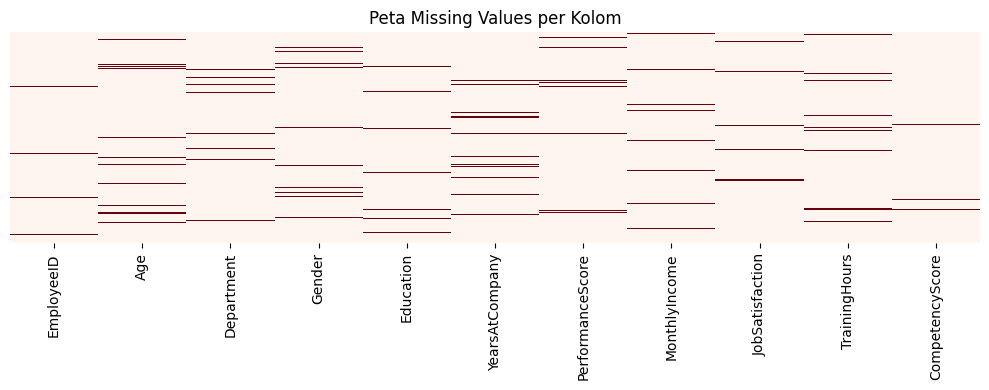

In [9]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='Reds')
plt.title('Peta Missing Values per Kolom')
plt.tight_layout()
plt.show()

Missingnya Random   
Saran : median/mode imputation

In [10]:
missing_ID = df[df['EmployeeID'].isna()]
missing_ID.head()

,EmployeeID,Age,Department,Gender,Education,YearsAtCompany,PerformanceScore,MonthlyIncome,JobSatisfaction,TrainingHours,CompetencyScore
16,NaN,44.0,Engineering,Male,High School,16.0,3.0,15334.0,2.0,77.0,1.0
17,NaN,50.0,Operations,Male,Master,18.0,2.0,5360.0,3.0,96.0,3.0
39,NaN,29.0,Operations,Female,Bachelor,5.0,3.0,4166.0,4.0,NaN,3.0
85,NaN,55.0,Sales,Male,Bachelor,8.0,4.0,2875.0,3.0,42.0,3.0
96,NaN,53.0,Operations,Male,NaN,3.0,3.0,2376.0,2.0,17.0,2.0


In [11]:
df.iloc[14:20]

,EmployeeID,Age,Department,Gender,Education,YearsAtCompany,PerformanceScore,MonthlyIncome,JobSatisfaction,TrainingHours,CompetencyScore
14,15.0,42.0,HR,Female,PhD,18.0,4.0,20902.0,1.0,76.0,1.0
15,16.0,22.0,Marketing,Female,PhD,17.0,3.0,9915.0,2.0,67.0,1.0
16,NaN,44.0,Engineering,Male,High School,16.0,3.0,15334.0,2.0,77.0,1.0
17,NaN,50.0,Operations,Male,Master,18.0,2.0,5360.0,3.0,96.0,3.0
18,19.0,58.0,Finance,Female,PhD,20.0,5.0,11200.0,2.0,91.0,NaN
19,20.0,22.0,Sales,Female,PhD,13.0,2.0,22558.0,4.0,51.0,4.0


In [12]:
df.iloc[37:42]

,EmployeeID,Age,Department,Gender,Education,YearsAtCompany,PerformanceScore,MonthlyIncome,JobSatisfaction,TrainingHours,CompetencyScore
37,38.0,45.0,Engineering,Female,PhD,7.0,NaN,8240.0,5.0,56.0,3.0
38,39.0,34.0,Engineering,Male,PhD,18.0,3.0,10648.0,5.0,29.0,3.0
39,NaN,29.0,Operations,Female,Bachelor,5.0,3.0,4166.0,4.0,NaN,3.0
40,41.0,46.0,Operations,Female,Master,2.0,4.0,17055.0,4.0,25.0,3.0
41,42.0,22.0,Marketing,Male,Bachelor,4.0,3.0,23682.0,2.0,1.0,2.0


In [13]:
df.iloc[83:88]

,EmployeeID,Age,Department,Gender,Education,YearsAtCompany,PerformanceScore,MonthlyIncome,JobSatisfaction,TrainingHours,CompetencyScore
83,84.0,37.0,Engineering,Male,Bachelor,7.0,3.0,16584.0,4.0,52.0,3.0
84,85.0,28.0,HR,Male,High School,4.0,NaN,14689.0,1.0,69.0,5.0
85,NaN,55.0,Sales,Male,Bachelor,8.0,4.0,2875.0,3.0,42.0,3.0
86,87.0,55.0,Finance,Female,High School,0.0,3.0,7054.0,3.0,59.0,4.0
87,88.0,53.0,Engineering,Male,Master,3.0,3.0,18265.0,3.0,57.0,3.0


In [14]:
df.iloc[94:99]

,EmployeeID,Age,Department,Gender,Education,YearsAtCompany,PerformanceScore,MonthlyIncome,JobSatisfaction,TrainingHours,CompetencyScore
94,95.0,32.0,Operations,Female,Master,13.0,3.0,7793.0,2.0,97.0,2.0
95,96.0,54.0,Marketing,Male,High School,13.0,3.0,4403.0,2.0,89.0,4.0
96,NaN,53.0,Operations,Male,NaN,3.0,3.0,2376.0,2.0,17.0,2.0
97,98.0,43.0,Finance,Female,NaN,5.0,4.0,21915.0,3.0,84.0,4.0
98,99.0,44.0,Finance,Female,PhD,10.0,NaN,3294.0,3.0,99.0,3.0


Karena EmployeeID polanya sequential (berurutan) bukan random, jadi kita imputasi sesuai urutan datanya

In [15]:
# Interpolate mengikuti urutan angka
df['EmployeeID'] = df['EmployeeID'].interpolate(method='linear')

print(df['EmployeeID'].isnull().sum())

0


In [16]:
df[['EmployeeID']].iloc[14:20]

,EmployeeID
14,15.0
15,16.0
16,17.0
17,18.0
18,19.0
19,20.0


Done

## **Cek Outlier**

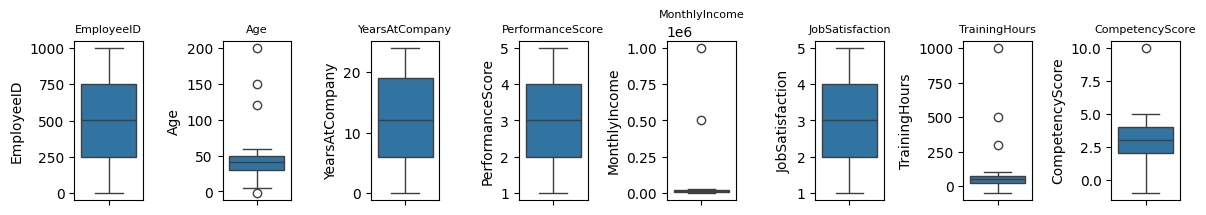

In [17]:
plt.figure(figsize=(12, 4))
for i in range(0, len(numeric)):
    plt.subplot(2, 8, i+1)
    sns.boxplot(y=df[numeric[i]], orient='v')
    plt.title(numeric[i], fontsize=8)  # ← tambah ini
    plt.tight_layout()

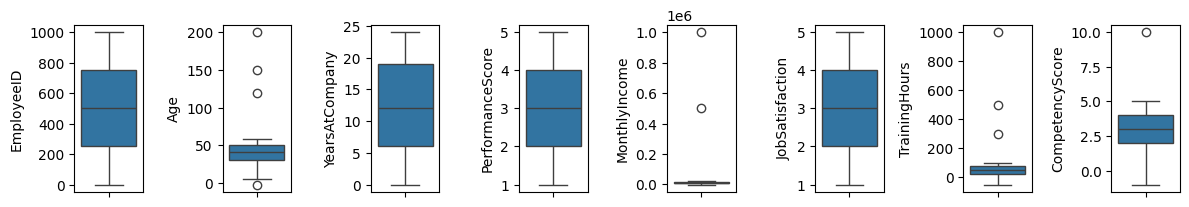

In [18]:
plt.figure(figsize = (12,4))
for i in range(0, len(numeric)):
    plt.subplot(2, 8, i+1)
    sns.boxplot(y = df[numeric[i]], orient='v')
    plt.tight_layout()

## **EDA**

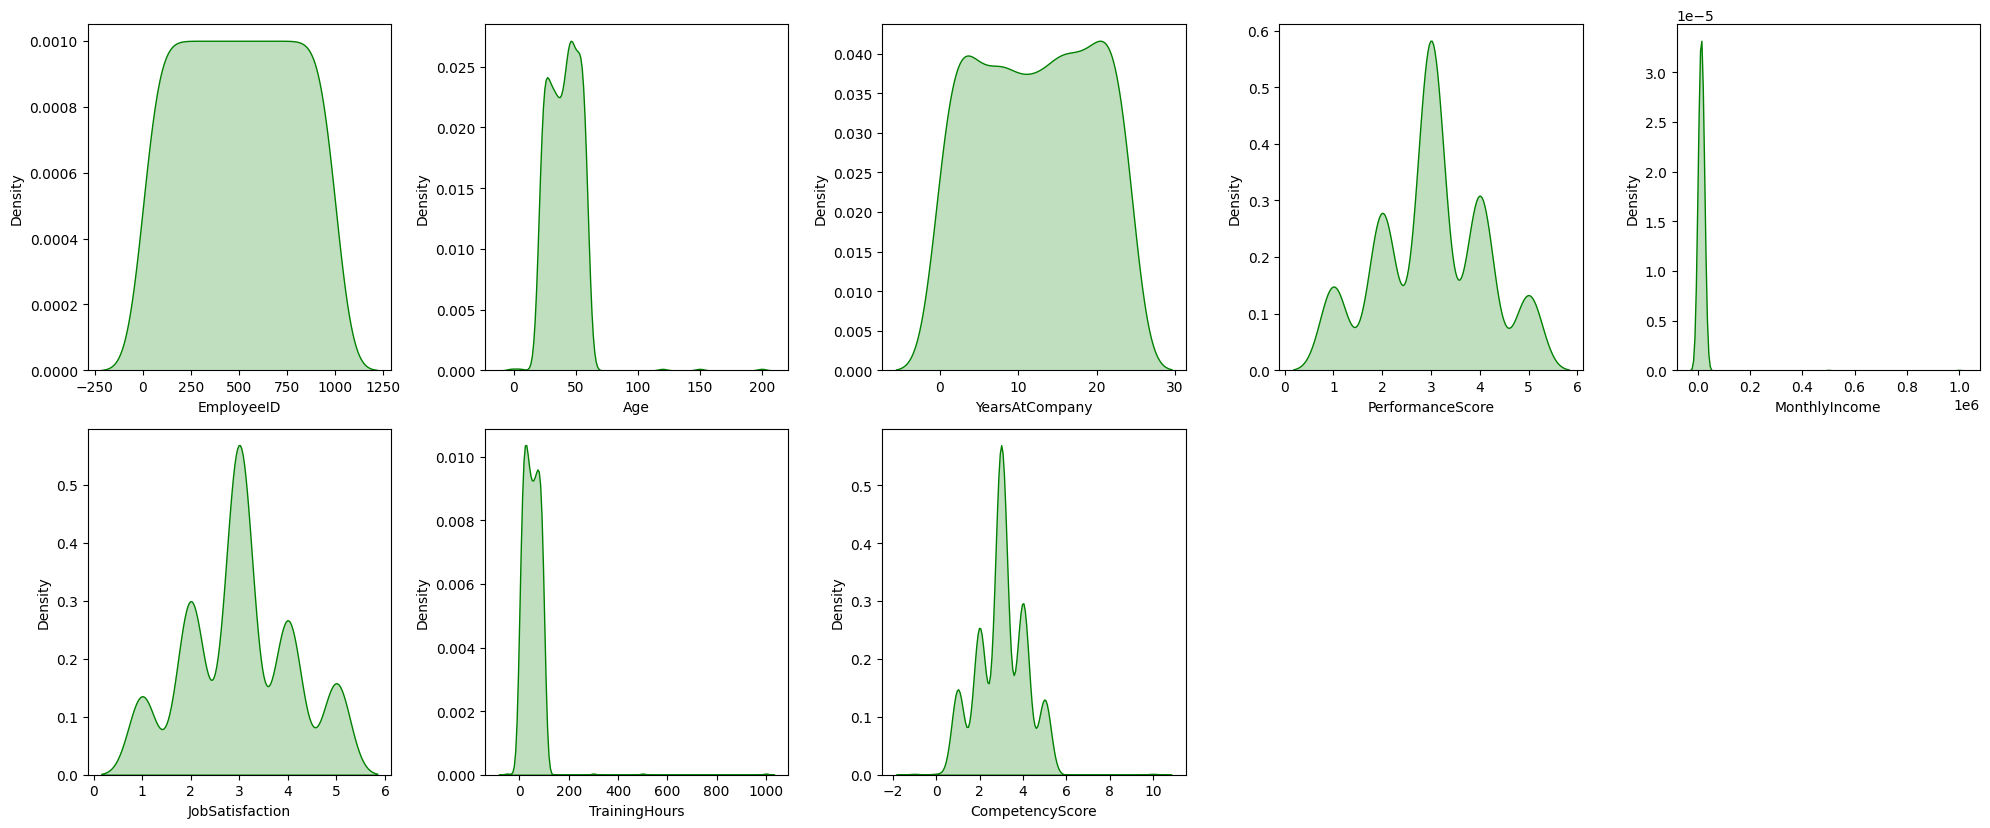

In [19]:
plt.figure(figsize=(20, 12))
for i in range(0, len(numeric)):
    plt.subplot(3, 5, i+1)
    sns.kdeplot(df[numeric[i]], color='green', fill=True)
    plt.tight_layout()
plt.show()

1. MonthlyIncome yang > 100000 dianggap tidak valid, akan di drop
2. Age yang < 18 dan > 70 dianggap tidak valid, akan di drop
3. TrainingHours < 0 tidak valid, akan di drop
4. CompetencyScore < 0 dan > 10 tidak valid, akan di drop

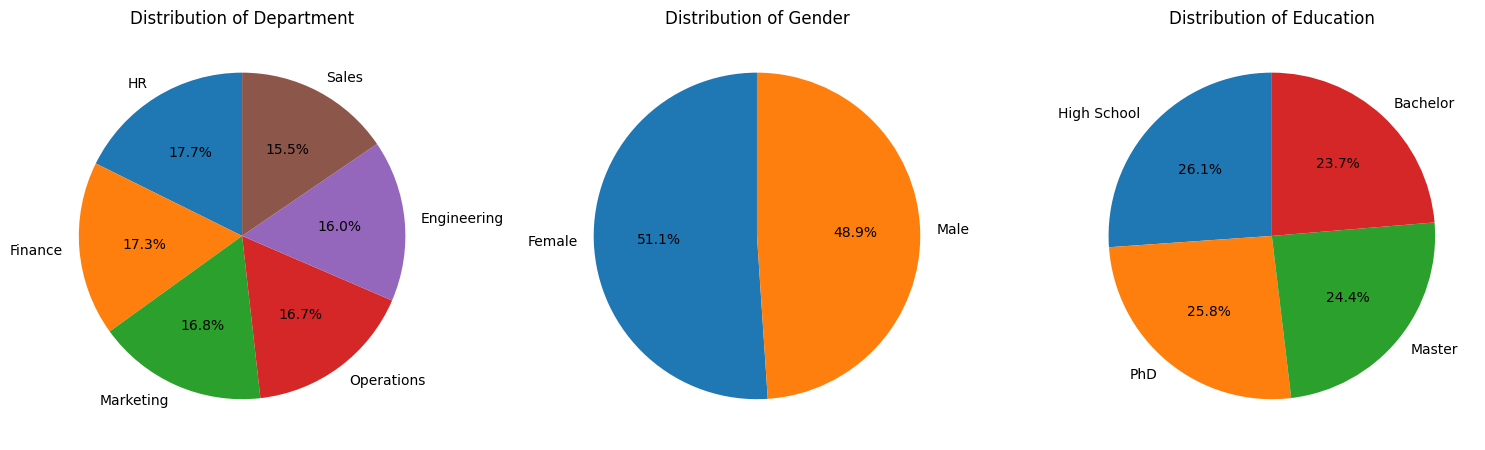

In [20]:
categorical = ['Department', 'Gender', 'Education']

fig, axes = plt.subplots(1, len(categorical), figsize=(15, 5))

for i, col in enumerate(categorical):
    axes[i].pie(
        df[col].value_counts(),
        labels=df[col].value_counts().index,
        autopct='%1.1f%%',
        startangle=90
    )
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

<Axes: >

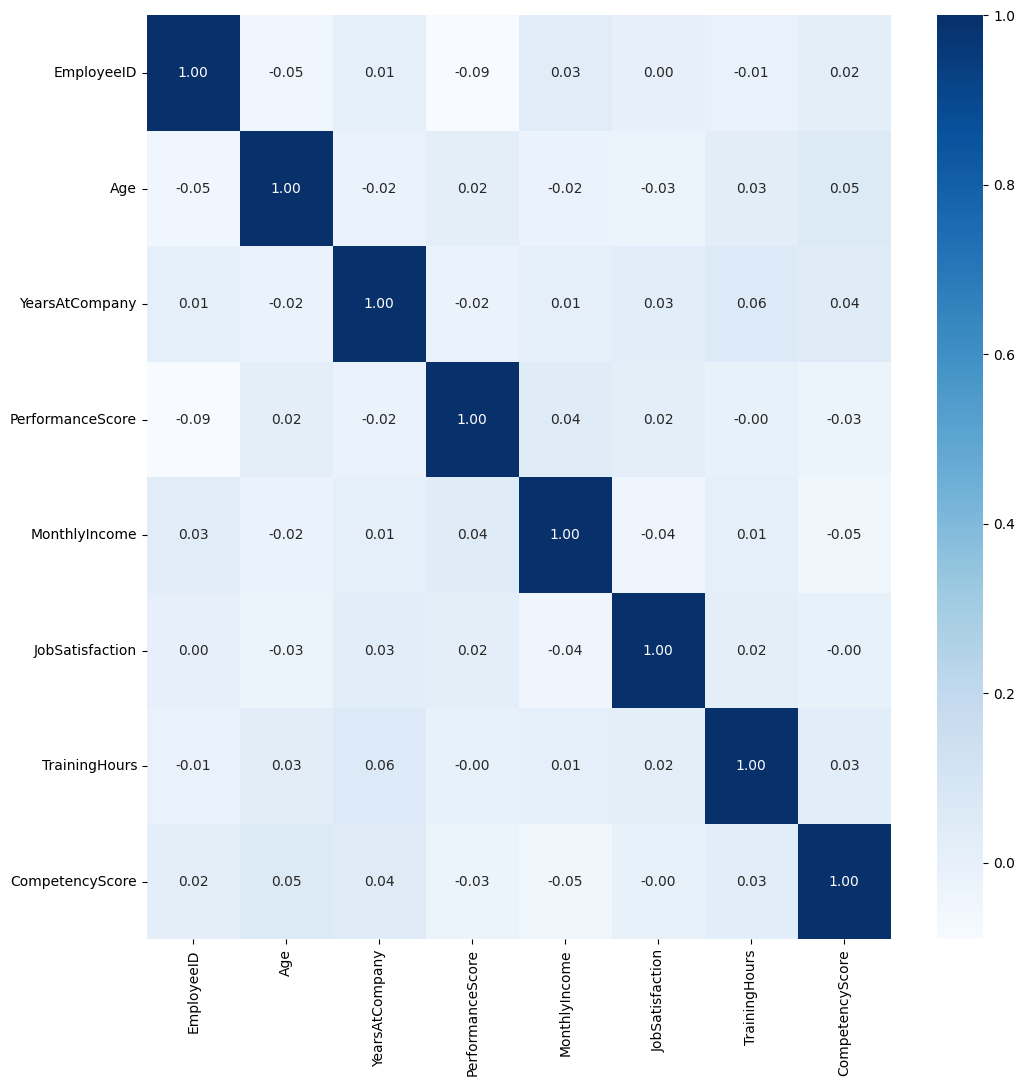

In [21]:
plt.figure(figsize=(12, 12))
sns.heatmap(df.corr(numeric_only=True), cmap='Blues', annot=True, fmt='.2f')

## **Cek Anomali**

In [22]:
# Lihat baris dengan Age anomali
df[(df['Age'] < 18) | (df['Age'] > 70)]

,EmployeeID,Age,Department,Gender,Education,YearsAtCompany,PerformanceScore,MonthlyIncome,JobSatisfaction,TrainingHours,CompetencyScore
77,78.0,200.0,Engineering,Male,PhD,4.0,2.0,8054.0,2.0,NaN,5.0
178,179.0,5.0,Operations,Male,PhD,10.0,3.0,1952.0,3.0,91.0,1.0
403,404.0,150.0,HR,Female,Master,NaN,5.0,6770.0,4.0,48.0,4.0
440,441.0,120.0,Engineering,Male,Bachelor,17.0,5.0,20890.0,2.0,17.0,5.0
786,787.0,-2.0,Sales,Female,PhD,24.0,3.0,19867.0,5.0,86.0,4.0


In [23]:
# Lihat baris dengan MonthlyIncome anomali
df[(df['MonthlyIncome'] < 0) | (df['MonthlyIncome'] > 100000)]

,EmployeeID,Age,Department,Gender,Education,YearsAtCompany,PerformanceScore,MonthlyIncome,JobSatisfaction,TrainingHours,CompetencyScore
171,172.0,NaN,Sales,Male,Bachelor,11.0,1.0,-500.0,4.0,49.0,3.0
368,369.0,21.0,HR,Male,Master,15.0,4.0,-1000.0,3.0,83.0,3.0
708,709.0,24.0,Finance,Male,NaN,15.0,5.0,999999.0,NaN,68.0,1.0
835,836.0,58.0,HR,Female,High School,10.0,2.0,500000.0,2.0,NaN,3.0


In [24]:
# Lihat baris dengan TrainingHours anomali
df[(df['TrainingHours'] < 0) | (df['TrainingHours'] > 200)]

,EmployeeID,Age,Department,Gender,Education,YearsAtCompany,PerformanceScore,MonthlyIncome,JobSatisfaction,TrainingHours,CompetencyScore
56,57.0,46.0,Finance,Male,High School,15.0,5.0,NaN,3.0,300.0,2.0
145,146.0,59.0,HR,Male,High School,24.0,4.0,12554.0,4.0,1000.0,4.0
858,859.0,NaN,Marketing,Female,Master,0.0,2.0,8333.0,3.0,-50.0,3.0
934,935.0,44.0,Marketing,Female,PhD,24.0,1.0,11823.0,3.0,-10.0,3.0
973,974.0,NaN,Marketing,Male,High School,19.0,3.0,10350.0,4.0,500.0,4.0


In [25]:
# Lihat baris dengan CompetencyScore anomali
df[(df['CompetencyScore'] < 0) | (df['CompetencyScore'] > 5)]

,EmployeeID,Age,Department,Gender,Education,YearsAtCompany,PerformanceScore,MonthlyIncome,JobSatisfaction,TrainingHours,CompetencyScore
154,155.0,47.0,NaN,Female,Master,21.0,4.0,19633.0,5.0,32.0,10.0
680,681.0,54.0,Sales,Male,PhD,5.0,4.0,16568.0,5.0,3.0,-1.0


In [26]:
# Cek Age vs YearsAtCompany yang tidak masuk akal
# Asumsi: mulai kerja minimal usia 18 tahun

anomali = df[df['Age'] - df['YearsAtCompany'] < 18]

print(f"Jumlah anomali: {len(anomali)}")

Jumlah anomali: 224


In [27]:
print(anomali[['EmployeeID', 'Age', 'YearsAtCompany']])

     EmployeeID   Age  YearsAtCompany
2           3.0  35.0            19.0
9          10.0  31.0            23.0
13         14.0  23.0            24.0
15         16.0  22.0            17.0
19         20.0  22.0            13.0
..          ...   ...             ...
984       985.0  21.0            24.0
987       988.0  29.0            17.0
988       989.0  29.0            19.0
994       995.0  31.0            22.0
996       997.0  22.0            19.0

[224 rows x 3 columns]


GA MASUK AKAL????????? drop salah satu

In [28]:
print("Age        :", df['Age'].min(), "–", df['Age'].max())
print("MonthlyIncome :", df['MonthlyIncome'].min(), "–", df['MonthlyIncome'].max())
print("TrainingHours :", df['TrainingHours'].min(), "–", df['TrainingHours'].max())
print("CompetencyScore:", df['CompetencyScore'].min(), "–", df['CompetencyScore'].max())
print("YearsAtCompany > Age :", (df['YearsAtCompany'] > df['Age']).sum())
print("Age - YearsAtCompany < 18 :", (df['Age'] - df['YearsAtCompany'] < 18).sum())

Age        : -2.0 – 200.0
MonthlyIncome : -1000.0 – 999999.0
TrainingHours : -50.0 – 1000.0
CompetencyScore: -1.0 – 10.0
YearsAtCompany > Age : 11
Age - YearsAtCompany < 18 : 224


## **Ubah Anomali Data Jadi Missing Data**

In [29]:
conditions = {
    'Age':           (df['Age'] < 18)           | (df['Age'] > 70),
    'MonthlyIncome': (df['MonthlyIncome'] < 0)  | (df['MonthlyIncome'] > 100000),
    'TrainingHours': (df['TrainingHours'] < 0)  | (df['TrainingHours'] > 200),
    'CompetencyScore': (df['CompetencyScore'] < 0) | (df['CompetencyScore'] > 5),
}

for col, cond in conditions.items():
    df.loc[cond, col] = np.nan

total_outlier_cells = sum(cond.sum() for cond in conditions.values())
print(f"Nilai diubah jadi NaN : {total_outlier_cells}")
print(f"Sisa data             : {len(df)}")

Nilai diubah jadi NaN : 16
Sisa data             : 1000


## **Handling Missing Value**

In [30]:
df.isna().sum()

EmployeeID           0
Age                 55
Department          50
Gender              50
Education           50
YearsAtCompany      50
PerformanceScore    50
MonthlyIncome       54
JobSatisfaction     50
TrainingHours       55
CompetencyScore     52
dtype: int64

In [31]:
# 1. Kategorikal → mode global (Department duluan, karena jadi grouping key)
categorical_cols = ['Department', 'Gender', 'Education']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 2. Numerik → median per Department (Department sudah lengkap, tidak ada grup NaN)
numerical_cols = ['Age', 'YearsAtCompany', 'PerformanceScore',
                  'MonthlyIncome', 'JobSatisfaction', 'TrainingHours', 'CompetencyScore']

for col in numerical_cols:
    df[col] = df.groupby('Department')[col].transform(
        lambda x: x.fillna(x.median())
    )
    # Fallback: kalau grup juga kosong, pakai median global
    df[col] = df[col].fillna(df[col].median())

# Verifikasi
print("Missing values setelah imputasi:")
print(df.isnull().sum())

Missing values setelah imputasi:
EmployeeID          0
Age                 0
Department          0
Gender              0
Education           0
YearsAtCompany      0
PerformanceScore    0
MonthlyIncome       0
JobSatisfaction     0
TrainingHours       0
CompetencyScore     0
dtype: int64


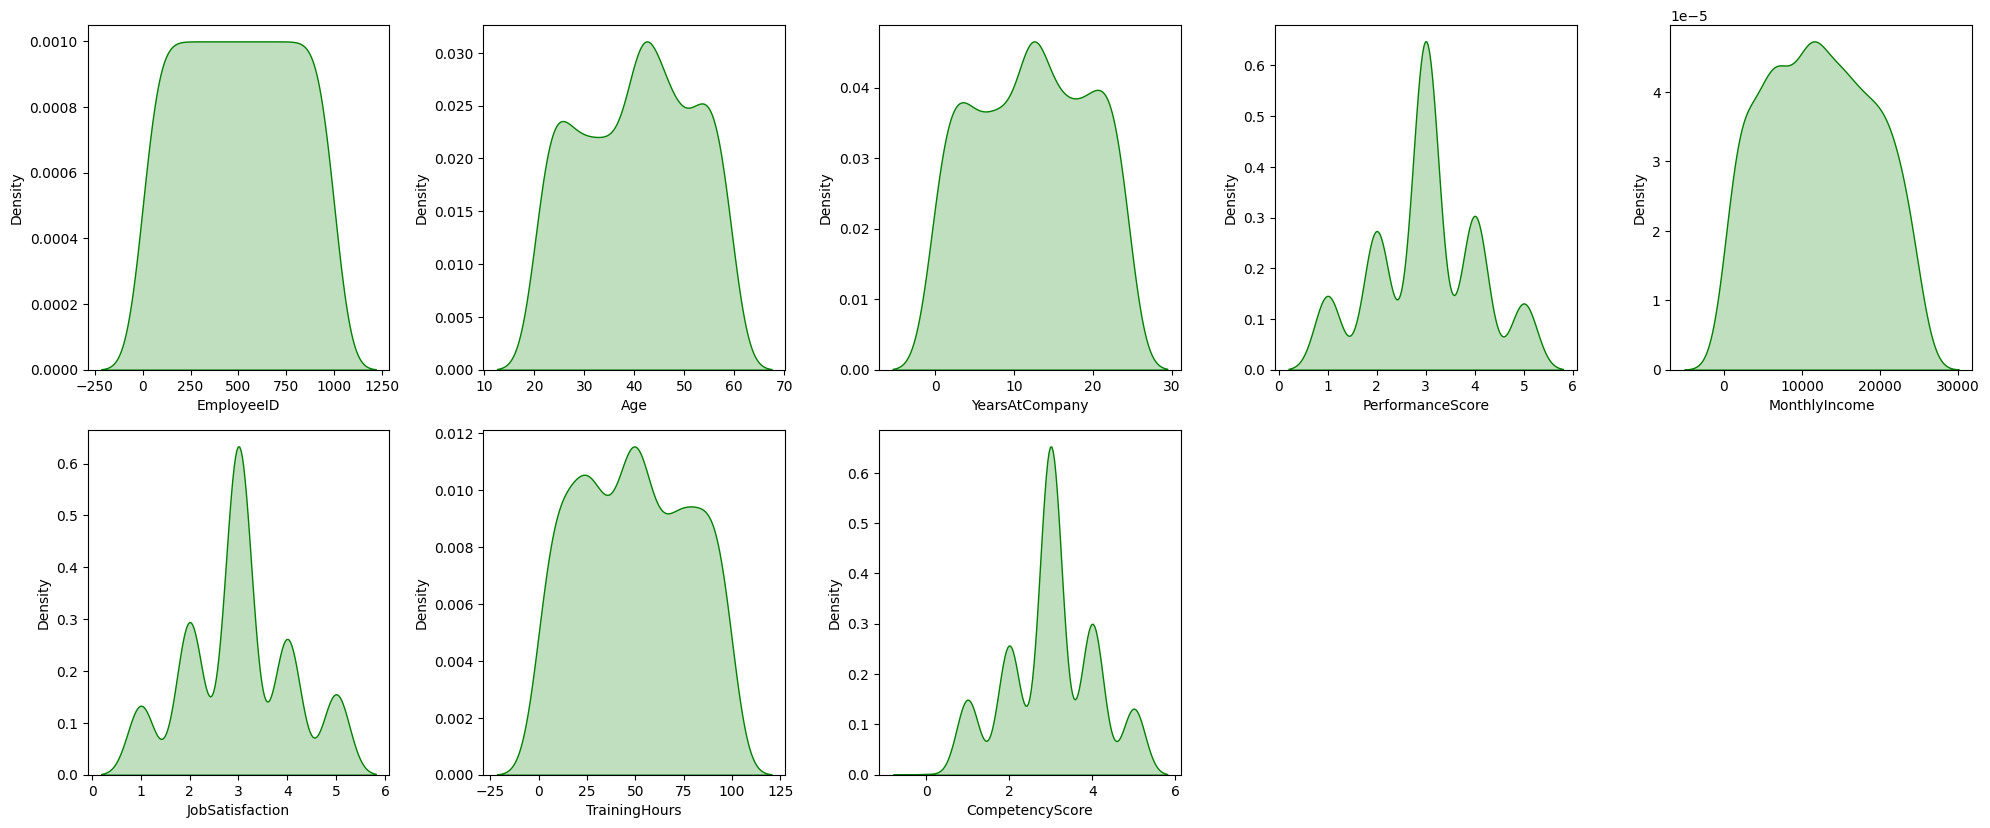

In [32]:
plt.figure(figsize=(20, 12))
for i in range(0, len(numeric)):
    plt.subplot(3, 5, i+1)
    sns.kdeplot(df[numeric[i]], color='green', fill=True)
    plt.tight_layout()
plt.show()

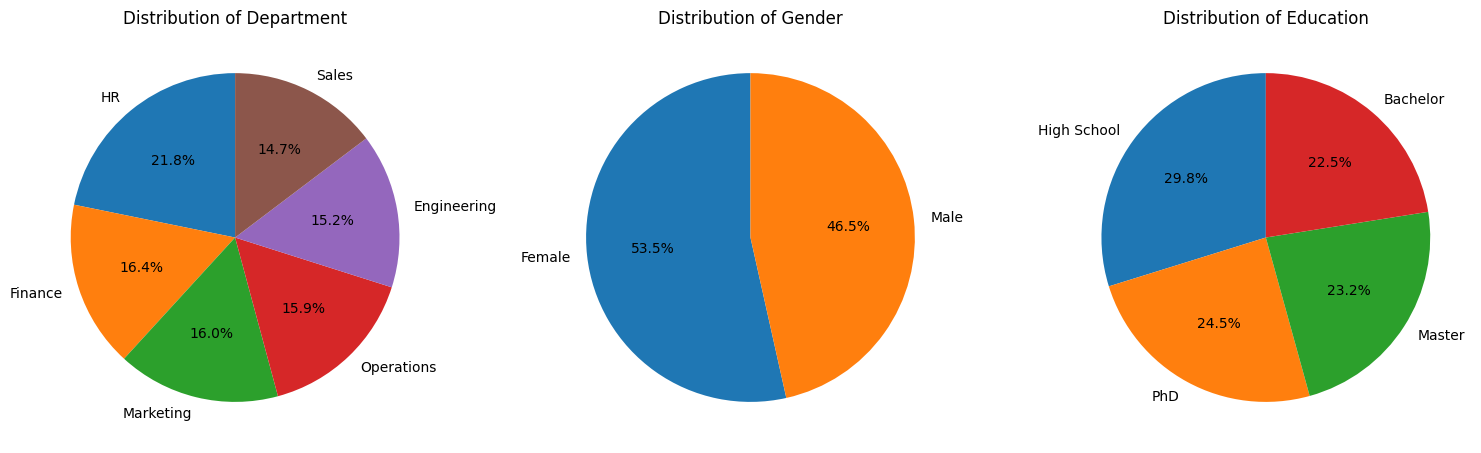

In [33]:
categorical = ['Department', 'Gender', 'Education']

fig, axes = plt.subplots(1, len(categorical), figsize=(15, 5))

for i, col in enumerate(categorical):
    axes[i].pie(
        df[col].value_counts(),
        labels=df[col].value_counts().index,
        autopct='%1.1f%%',
        startangle=90
    )
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

<Axes: >

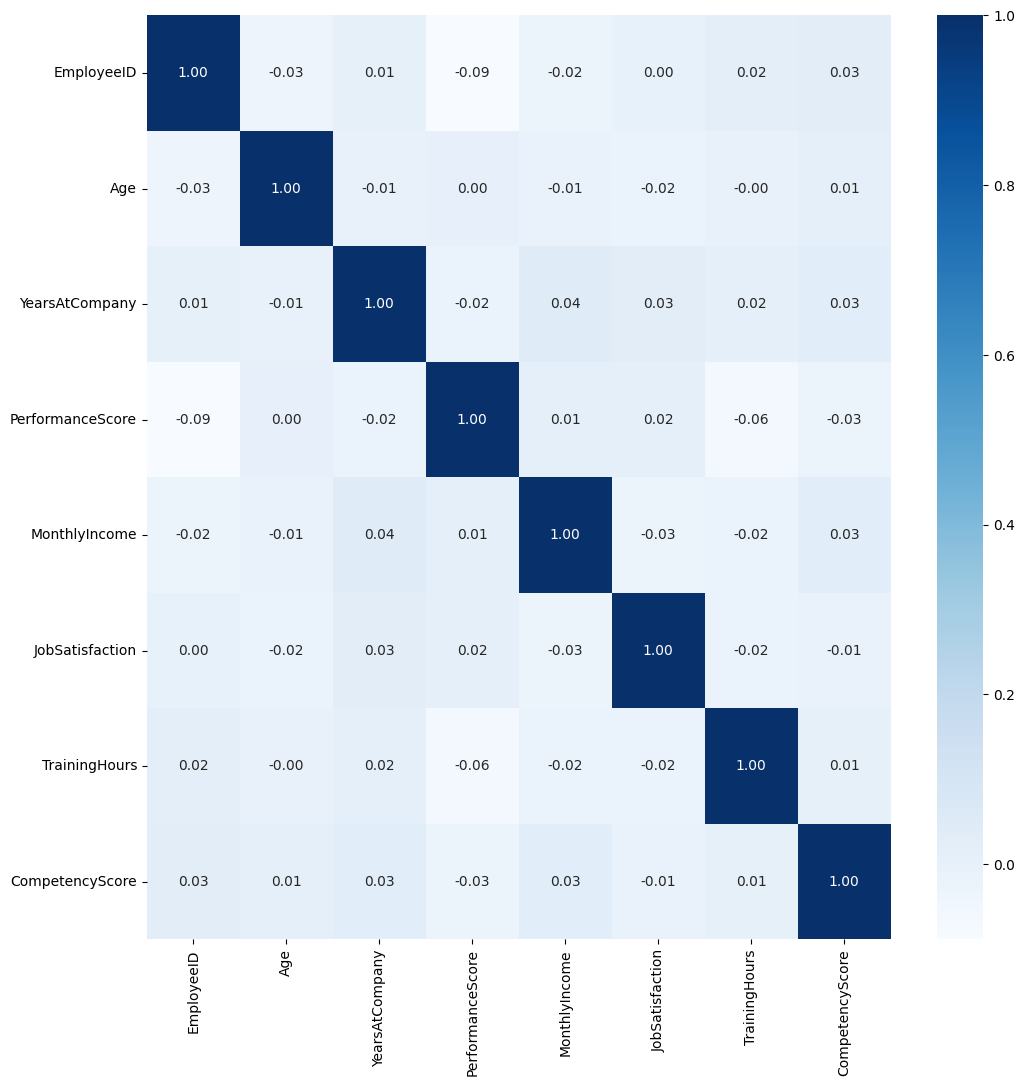

In [34]:
plt.figure(figsize=(12, 12))
sns.heatmap(df.corr(numeric_only=True), cmap='Blues', annot=True, fmt='.2f')

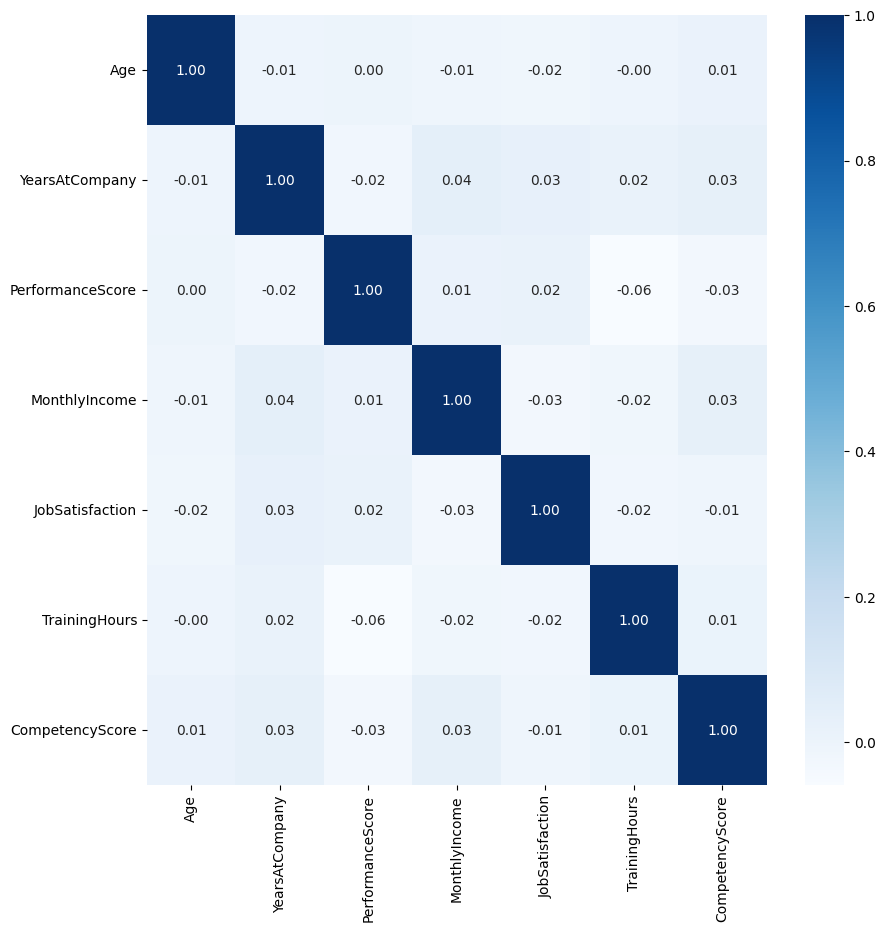

In [35]:
df_numeric = df.corr(numeric_only=True).drop(index='EmployeeID', columns='EmployeeID', errors='ignore')

plt.figure(figsize=(10, 10))  # Ukuran sedikit dikecilkan agar lebih proporsional setelah 1 kolom hilang
sns.heatmap(df_numeric, cmap='Blues', annot=True, fmt='.2f', cbar=True)
plt.show()

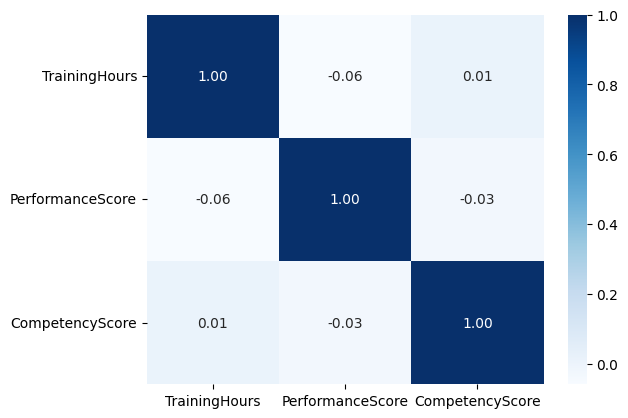

In [36]:
corr = df[['TrainingHours', 'PerformanceScore', 'CompetencyScore']].corr()

sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.show()

### **Insight**

Jam pelatihan yang tinggi tidak menjamin peningkatan performa maupun kompetensi karyawan. Hal ini mengindikasikan bahwa program pelatihan yang ada saat ini kemungkinan tidak tepat sasaran, kurang relevan dengan kebutuhan aktual karyawan, atau kualitasnya perlu dievaluasi ulang

## **Feature Selection**

In [37]:
df.head()

,EmployeeID,Age,Department,Gender,Education,YearsAtCompany,PerformanceScore,MonthlyIncome,JobSatisfaction,TrainingHours,CompetencyScore
0,1.0,59.0,Finance,Female,Bachelor,11.0,1.0,14031.0,2.0,43.0,4.0
1,2.0,49.0,HR,Male,Master,11.0,1.0,7489.0,2.0,79.0,2.0
2,3.0,35.0,HR,Male,Master,19.0,5.0,14841.0,1.0,74.0,2.0
3,4.0,28.0,Engineering,Female,Bachelor,5.0,3.0,11178.0,2.0,13.0,5.0
4,5.0,41.0,Engineering,Male,Master,22.0,3.0,11387.0,3.0,2.0,1.0


### Fitur yang Dipakai

| Fitur | Alasan |
|---|---|
| `PerformanceScore` | Inti dari career development, siapa yang perlu didorong atau dikembangkan? |
| `JobSatisfaction` | Indikator retensi dan motivasi (risiko resign sebelum berkembang) |
| `YearsAtCompany` | Menentukan level senioritas & pipeline leadership |
| `MonthlyIncome` | Indikator risiko turnover (karyawan berperforma tinggi dengan income rendah berpotensi resign)|

###  Fitur yang Di-drop saat clustering

| Fitur | Alasan |
|---|---|
| `CompetencyScore` | Representasi kemampuan keseluruhan (Technical, Leadership, Communication, Problem Solving, Teamwork, Adaptability) |
| `EmployeeID` | Tidak bermakna secara analitik |
| `Gender` | Tidak relevan untuk career clustering, bisa menimbulkan bias |
| `Department` | Terlalu spesifik hanya kebutuhan imputasi data menggunakan median per departemen, Department dipakai untuk breakdown hasil per departemen (Post-clustering analysis )
| `Age` | Tumpang tindih dengan YearsAtCompany menyebabkan anomali data sebanyak 224 |
| `Education` | Lebih mencerminkan latar belakang, bukan performa aktual karyawan saat ini |
| `TrainingHours` | Menunjukkan engagement terhadap pengembangan diri |


## **Feature Extraction**

Untuk feature selection dan extraction dilakukan sesuai kebutuhan

Clustering dulu, kalau jelek hasilnya gunakan fitur extraction

## **Feature Engineering**

In [38]:
# Disimpan untuk post-clustering analysis
df_meta = df[['EmployeeID', 'Department', 'Gender', 'Education']].copy()

# Fitur yang dipakai untuk clustering
clustering_features = [
    'PerformanceScore',   # Inti career development
    'JobSatisfaction',    # Indikator retensi & motivasi
    'YearsAtCompany',     # Senioritas & pipeline leadership
    'MonthlyIncome'       # Indikator risiko turnover
]

# DataFrame untuk clustering
df_clustering = df[clustering_features].copy()

In [39]:
df_meta.head()

,EmployeeID,Department,Gender,Education
0,1.0,Finance,Female,Bachelor
1,2.0,HR,Male,Master
2,3.0,HR,Male,Master
3,4.0,Engineering,Female,Bachelor
4,5.0,Engineering,Male,Master


In [40]:
df_clustering.head()

,PerformanceScore,JobSatisfaction,YearsAtCompany,MonthlyIncome
0,1.0,2.0,11.0,14031.0
1,1.0,2.0,11.0,7489.0
2,5.0,1.0,19.0,14841.0
3,3.0,2.0,5.0,11178.0
4,3.0,3.0,22.0,11387.0


## **Standarisasi**

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clustering)

# Konversi ke DataFrame
df_scaled = pd.DataFrame(df_scaled, columns=clustering_features)

In [42]:
df_scaled.head()

,PerformanceScore,JobSatisfaction,YearsAtCompany,MonthlyIncome
0,-1.889822,-0.937548,-0.168593,0.277243
1,-1.889822,-0.937548,-0.168593,-0.692401
2,1.889822,-1.867656,0.950699,0.397299
3,0.000000,-0.937548,-1.008062,-0.145624
4,0.000000,-0.007441,1.370433,-0.114646


## **Model**

pakai yang df_scaled buat masuk modelnya yaa

Daripada kayak gini mending dipisah2 modelingnya

# Stage 2 — Retention & Engagement Workforce Segmentation

Membangun segmentasi karyawan berdasarkan pola **retention dan engagement** secara agregat untuk membantu HR memahami pola workforce dan menentukan area follow-up yang lebih terarah.

## Setup & Feature Preparation

In [43]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from itertools import product

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# 1. Gunakan kolom yang sudah ada langsung dari df_scaled
feats = df_scaled.columns.tolist()

# 2. Assign X langsung dari df_scaled yang sudah di-scale sebelumnya
X = df_scaled.values

# 3. Asumsi 'df' (dataframe original) masih tersimpan di memory untuk mengambil metadata
df_meta = df[['EmployeeID', 'Department', 'Gender', 'Education']].copy()

def evaluate(X, labels):
    n = len(set(labels)) - (1 if -1 in labels else 0)
    if n < 2: return None, None, None

    mask = labels != -1
    if mask.sum() < 2: return None, None, None

    return (silhouette_score(X[mask], labels[mask]),
            davies_bouldin_score(X[mask], labels[mask]),
            calinski_harabasz_score(X[mask], labels[mask]))

print("Feature set:", feats)
print("Shape:", X.shape)

Feature set: ['PerformanceScore', 'JobSatisfaction', 'YearsAtCompany', 'MonthlyIncome']
Shape: (1000, 4)


## Step 1 — Grid Search k (Model Selection)

Cari k terbaik untuk setiap model dengan membandingkan 3 metrik:
- **Silhouette** → makin tinggi makin baik (max 1.0)
- **Davies-Bouldin** → makin rendah makin baik
- **Calinski-Harabasz** → makin tinggi makin baik

In [44]:
k_range = range(2, 7)
grid_results = []
best_k = {}

for model_name in ['KMeans', 'Agglomerative', 'GMM']:
    print(f"--- {model_name} ---")
    best_sil, best_k_val = -999, 2
    for k in k_range:
        if model_name == 'KMeans':
            m = KMeans(n_clusters=k, random_state=42, n_init=10)
        elif model_name == 'Agglomerative':
            m = AgglomerativeClustering(n_clusters=k, linkage='ward')
        else:
            m = GaussianMixture(n_components=k, random_state=42)
        labels = m.fit_predict(X)
        sil, db, ch = evaluate(X, labels)
        grid_results.append({'model': model_name, 'k': k,
                              'silhouette': round(sil,4),
                              'davies_bouldin': round(db,4),
                              'calinski_harabasz': round(ch,1)})
        print(f"  k={k} | Sil={sil:.4f} | DB={db:.4f} | CH={ch:.1f}")
        if sil > best_sil:
            best_sil, best_k_val = sil, k
    best_k[model_name] = best_k_val
    print(f"  → Best k={best_k_val}\n")

--- KMeans ---
  k=2 | Sil=0.1854 | DB=1.9777 | CH=228.4
  k=3 | Sil=0.1838 | DB=1.6534 | CH=222.8
  k=4 | Sil=0.1870 | DB=1.4585 | CH=215.6
  k=5 | Sil=0.1948 | DB=1.3417 | CH=213.7
  k=6 | Sil=0.1916 | DB=1.3611 | CH=207.4
  → Best k=5

--- Agglomerative ---
  k=2 | Sil=0.1377 | DB=2.3200 | CH=165.7
  k=3 | Sil=0.1384 | DB=1.9280 | CH=168.7
  k=4 | Sil=0.1261 | DB=1.7974 | CH=161.3
  k=5 | Sil=0.1241 | DB=1.6795 | CH=154.6
  k=6 | Sil=0.1212 | DB=1.5146 | CH=154.0
  → Best k=3

--- GMM ---
  k=2 | Sil=0.1698 | DB=2.0884 | CH=207.5
  k=3 | Sil=0.1443 | DB=1.7796 | CH=161.9
  k=4 | Sil=0.1645 | DB=1.5711 | CH=179.0
  k=5 | Sil=0.1571 | DB=1.5959 | CH=182.1
  k=6 | Sil=0.1515 | DB=1.5602 | CH=169.6
  → Best k=2



## Step 2 — Hyperparameter Tuning

Dengan k terbaik dari Step 1, sekarang tuning parameter spesifik tiap model:
- **KMeans**: `init` (k-means++ vs random) × `n_init` × `max_iter`
- **Agglomerative**: `linkage` (ward / complete / average / single)
- **GMM**: `covariance_type` (full / tied / diag / spherical) × `max_iter`
- **DBSCAN**: `eps` × `min_samples` (tidak pakai k — jumlah cluster ditentukan otomatis)

In [45]:
tuning_results = []

# KMeans
k = best_k['KMeans']
print(f"--- KMeans (k={k}) | Tuning: init × n_init × max_iter ---")
for init, n_init, max_iter in product(['k-means++', 'random'], [10, 20, 50], [100, 300]):
    m = KMeans(n_clusters=k, init=init, n_init=n_init, max_iter=max_iter, random_state=42)
    labels = m.fit_predict(X)
    sil, db, ch = evaluate(X, labels)
    tuning_results.append({'model': 'KMeans', 'k': k,
                           'params': f"init={init}, n_init={n_init}, max_iter={max_iter}",
                           'silhouette': round(sil,4), 'davies_bouldin': round(db,4),
                           'calinski_harabasz': round(ch,1)})
    print(f"  init={init:10s} | n_init={n_init:2d} | max_iter={max_iter} "
          f"| Sil={sil:.4f} | DB={db:.4f} | CH={ch:.1f}")

# Agglomerative
k = best_k['Agglomerative']
print(f"\n--- Agglomerative (k={k}) | Tuning: linkage ---")
for linkage in ['ward', 'complete', 'average', 'single']:
    m = AgglomerativeClustering(n_clusters=k, linkage=linkage)
    labels = m.fit_predict(X)
    sil, db, ch = evaluate(X, labels)
    tuning_results.append({'model': 'Agglomerative', 'k': k,
                           'params': f"linkage={linkage}",
                           'silhouette': round(sil,4), 'davies_bouldin': round(db,4),
                           'calinski_harabasz': round(ch,1)})
    print(f"  linkage={linkage:8s} | Sil={sil:.4f} | DB={db:.4f} | CH={ch:.1f}")

# ── GMM ───
k = best_k['GMM']
print(f"\n--- GMM (k={k}) | Tuning: covariance_type × max_iter ---")
for cov_type, max_iter in product(['full', 'tied', 'diag', 'spherical'], [100, 300]):
    m = GaussianMixture(n_components=k, covariance_type=cov_type,
                        max_iter=max_iter, random_state=42)
    labels = m.fit_predict(X)
    sil, db, ch = evaluate(X, labels)
    tuning_results.append({'model': 'GMM', 'k': k,
                           'params': f"cov={cov_type}, max_iter={max_iter}",
                           'silhouette': round(sil,4), 'davies_bouldin': round(db,4),
                           'calinski_harabasz': round(ch,1)})
    print(f"  cov={cov_type:10s} | max_iter={max_iter} "
          f"| Sil={sil:.4f} | DB={db:.4f} | CH={ch:.1f}")

# DBSCAN
print("\n--- DBSCAN | Tuning: eps × min_samples ---")
for eps, min_samples in product([0.3, 0.4, 0.5, 0.6, 0.7, 0.8], [3, 5, 10, 15, 20]):
    m = DBSCAN(eps=eps, min_samples=min_samples)
    labels = m.fit_predict(X)
    n_cl = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    sil, db, ch = evaluate(X, labels)
    if sil is not None:
        tuning_results.append({'model': 'DBSCAN', 'k': n_cl,
                               'params': f"eps={eps}, min_samples={min_samples}, noise={n_noise}",
                               'silhouette': round(sil,4), 'davies_bouldin': round(db,4),
                               'calinski_harabasz': round(ch,1)})
        print(f"  eps={eps} | min_s={min_samples:2d} | n_cl={n_cl:2d} "
              f"| noise={n_noise:3d} | Sil={sil:.4f} | DB={db:.4f}")

df_tuning = pd.DataFrame(tuning_results)

--- KMeans (k=5) | Tuning: init × n_init × max_iter ---
  init=k-means++  | n_init=10 | max_iter=100 | Sil=0.1948 | DB=1.3417 | CH=213.7
  init=k-means++  | n_init=10 | max_iter=300 | Sil=0.1948 | DB=1.3417 | CH=213.7
  init=k-means++  | n_init=20 | max_iter=100 | Sil=0.1976 | DB=1.3650 | CH=217.0
  init=k-means++  | n_init=20 | max_iter=300 | Sil=0.1976 | DB=1.3650 | CH=217.0
  init=k-means++  | n_init=50 | max_iter=100 | Sil=0.1976 | DB=1.3650 | CH=217.0
  init=k-means++  | n_init=50 | max_iter=300 | Sil=0.1976 | DB=1.3650 | CH=217.0
  init=random     | n_init=10 | max_iter=100 | Sil=0.1889 | DB=1.3659 | CH=214.0
  init=random     | n_init=10 | max_iter=300 | Sil=0.1889 | DB=1.3659 | CH=214.0
  init=random     | n_init=20 | max_iter=100 | Sil=0.1982 | DB=1.3702 | CH=216.9
  init=random     | n_init=20 | max_iter=300 | Sil=0.1982 | DB=1.3702 | CH=216.9
  init=random     | n_init=50 | max_iter=100 | Sil=0.1972 | DB=1.3621 | CH=217.0
  init=random     | n_init=50 | max_iter=300 | Sil=0.

## Step 3 — Best Configuration per Model

In [46]:
best_configs = []
print("=== BEST CONFIGURATION PER MODEL ===\n")
for model in ['KMeans', 'Agglomerative', 'GMM', 'DBSCAN']:
    sub = df_tuning[df_tuning['model'] == model].sort_values('silhouette', ascending=False)
    if len(sub):
        best = sub.iloc[0]
        best_configs.append(best.to_dict())
        print(f"{model}")
        print(f"  Params     : {best['params']}")
        print(f"  k/clusters : {int(best['k'])}")
        print(f"  Silhouette : {best['silhouette']:.4f}")
        print(f"  Davies-Bouldin    : {best['davies_bouldin']:.4f}")
        print(f"  Calinski-Harabasz : {best['calinski_harabasz']:.1f}")
        print()

=== BEST CONFIGURATION PER MODEL ===

KMeans
  Params     : init=random, n_init=20, max_iter=100
  k/clusters : 5
  Silhouette : 0.1982
  Davies-Bouldin    : 1.3702
  Calinski-Harabasz : 216.9

Agglomerative
  Params     : linkage=ward
  k/clusters : 3
  Silhouette : 0.1384
  Davies-Bouldin    : 1.9280
  Calinski-Harabasz : 168.7

GMM
  Params     : cov=full, max_iter=100
  k/clusters : 2
  Silhouette : 0.1698
  Davies-Bouldin    : 2.0884
  Calinski-Harabasz : 207.5

DBSCAN
  Params     : eps=0.5, min_samples=15, noise=919
  k/clusters : 2
  Silhouette : 0.5019
  Davies-Bouldin    : 0.5687
  Calinski-Harabasz : 96.9



## Step 4 — Analisis DBSCAN: Mengapa Dikeluarkan

DBSCAN menunjukkan silhouette tertinggi di antara semua konfigurasi, tapi **angka ini menyesatkan** dan perlu dievaluasi lebih kritis.

In [47]:
# Tampilkan konfigurasi DBSCAN terbaik dan jelaskan masalahnya
db_best = df_tuning[df_tuning['model'] == 'DBSCAN'].sort_values('silhouette', ascending=False).iloc[0]
print(f"DBSCAN best config: {db_best['params']}")
print(f"Silhouette: {db_best['silhouette']:.4f}")
print()

# Jalankan ulang buat lihat detail noise
for params in ['eps=0.5, min_samples=15', 'eps=0.3, min_samples=5']:
    eps_val = float(params.split(',')[0].split('=')[1])
    ms_val = int(params.split(',')[1].split('=')[1])
    m = DBSCAN(eps=eps_val, min_samples=ms_val)
    labels = m.fit_predict(X)
    n_cl = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    print(f"eps={eps_val}, min_samples={ms_val}")
    print(f"  n_clusters : {n_cl}")
    print(f"  n_noise    : {n_noise} ({n_noise/len(labels)*100:.1f}% dari total data)")
    print(f"  → Silhouette dihitung hanya dari {len(labels)-n_noise} data non-noise")
    print()

DBSCAN best config: eps=0.5, min_samples=15, noise=919
Silhouette: 0.5019

eps=0.5, min_samples=15
  n_clusters : 2
  n_noise    : 919 (91.9% dari total data)
  → Silhouette dihitung hanya dari 81 data non-noise

eps=0.3, min_samples=5
  n_clusters : 25
  n_noise    : 771 (77.1% dari total data)
  → Silhouette dihitung hanya dari 229 data non-noise



Silhouette tinggi bukan karena cluster-nya bagus, tapi karena mayoritas data (>77%) dibuang sebagai noise sebelum metrik dihitung. Ini bukan segmentasi yang valid untuk seluruh 1000 karyawan.

## Step 5 — Perbandingan Final & Pemilihan Model

Membandingkan model terbaik dari KMeans, Agglomerative, dan GMM (DBSCAN sudah dikeluarkan).

In [48]:
# Profil cluster tiap kandidat final
candidates = [
    ('KMeans',        best_k['KMeans'],        {'init': 'random', 'n_init': 20, 'max_iter': 100}),
    ('Agglomerative', best_k['Agglomerative'],  {'linkage': 'ward'}),
    ('GMM',           best_k['GMM'],            {'covariance_type': 'full', 'max_iter': 100}),
]

print("=== PROFIL CLUSTER TIAP KANDIDAT FINAL ===\n")
for model_name, k, params in candidates:
    if model_name == 'KMeans':
        m = KMeans(n_clusters=k, random_state=42, **params)
    elif model_name == 'Agglomerative':
        m = AgglomerativeClustering(n_clusters=k, **params)
    else:
        m = GaussianMixture(n_components=k, random_state=42, **params)
    labels = m.fit_predict(X)
    tmp = df[feats].copy()
    tmp['Cluster'] = labels
    sil, db, ch = evaluate(X, labels)
    print(f"--- {model_name} k={k} | Sil={sil:.4f} | DB={db:.4f} | CH={ch:.1f} ---")
    print(tmp.groupby('Cluster')[feats].mean().round(2))
    print(tmp['Cluster'].value_counts().sort_index())
    print()

=== PROFIL CLUSTER TIAP KANDIDAT FINAL ===

--- KMeans k=5 | Sil=0.1982 | DB=1.3702 | CH=216.9 ---
         PerformanceScore  JobSatisfaction  YearsAtCompany  MonthlyIncome
Cluster                                                                  
0                    3.71             3.04           16.88       18339.41
1                    3.18             3.63            4.03       11967.70
2                    3.26             3.48           16.29        5455.84
3                    2.95             1.61            7.88       10850.48
4                    1.46             3.08           15.58       14616.47
Cluster
0    225
1    210
2    224
3    182
4    159
Name: count, dtype: int64

--- Agglomerative k=3 | Sil=0.1384 | DB=1.9280 | CH=168.7 ---
         PerformanceScore  JobSatisfaction  YearsAtCompany  MonthlyIncome
Cluster                                                                  
0                    3.68             3.47           10.97       10163.99
1                  

In [49]:
# Tabel perbandingan final
final_compare = []
for model_name, k, params in candidates:
    if model_name == 'KMeans':
        m = KMeans(n_clusters=k, random_state=42, **params)
    elif model_name == 'Agglomerative':
        m = AgglomerativeClustering(n_clusters=k, **params)
    else:
        m = GaussianMixture(n_components=k, random_state=42, **params)
    labels = m.fit_predict(X)
    sil, db, ch = evaluate(X, labels)
    n_clusters_actual = len(set(labels))
    sizes = pd.Series(labels).value_counts().sort_index().tolist()
    final_compare.append({
        'Model': f"{model_name} (k={k})",
        'Best Params': str(params),
        'Silhouette': round(sil,4),
        'Davies-Bouldin': round(db,4),
        'Calinski-Harabasz': round(ch,1),
        'Cluster Sizes': str(sizes)
    })

df_final_compare = pd.DataFrame(final_compare)
print(df_final_compare.to_string(index=False))

              Model                                       Best Params  Silhouette  Davies-Bouldin  Calinski-Harabasz             Cluster Sizes
       KMeans (k=5) {'init': 'random', 'n_init': 20, 'max_iter': 100}      0.1982          1.3702              216.9 [225, 210, 224, 182, 159]
Agglomerative (k=3)                               {'linkage': 'ward'}      0.1384          1.9280              168.7           [445, 284, 271]
          GMM (k=2)      {'covariance_type': 'full', 'max_iter': 100}      0.1698          2.0884              207.5                [496, 504]


## Keputusan Model Final

Berdasarkan evaluasi Step 1–5:

| Model | Sil | DB | CH | Verdict |
|---|---|---|---|---|
| **KMeans k=5** (tuned) | 0.1982 | 1.3702 | 216.9 | **Terpilih (sejauh ini)** |
| Agglomerative k=3 (ward) | 0.1384 | 1.9280 | 168.7 | 2 metrik lebih rendah |
| GMM k=2 (full) | 0.1698 | 2.0884 | 207.5 | DB tertinggi, hanya 2 cluster |
| DBSCAN | - | - | - | 77–92% data jadi noise |

**KMeans k=5 (init=random, n_init=20) dipilih** karena:
1. Silhouette tertinggi di antara model yang valid (0.1982)
2. Davies-Bouldin terendah (1.3702) — cluster paling terpisah
3. Calinski-Harabasz kompetitif (216.9)
4. 5 cluster menghasilkan segmen yang lebih granular untuk follow-up HR

## Final Model: Fitting, Labeling & Output

In [50]:
# Final model dengan parameter terbaik
km_final = KMeans(n_clusters=5, init='random', n_init=20,
                  max_iter=100, random_state=42)
df['Cluster'] = km_final.fit_predict(X)

cluster_profile = df.groupby('Cluster')[feats].mean().round(2)
print("=== PROFIL CLUSTER FINAL (KMeans k=5) ===")
print(cluster_profile)
print()
print(df['Cluster'].value_counts().sort_index())

=== PROFIL CLUSTER FINAL (KMeans k=5) ===
         PerformanceScore  JobSatisfaction  YearsAtCompany  MonthlyIncome
Cluster                                                                  
0                    3.71             3.04           16.88       18339.41
1                    3.18             3.63            4.03       11967.70
2                    3.26             3.48           16.29        5455.84
3                    2.95             1.61            7.88       10850.48
4                    1.46             3.08           15.58       14616.47

Cluster
0    225
1    210
2    224
3    182
4    159
Name: count, dtype: int64


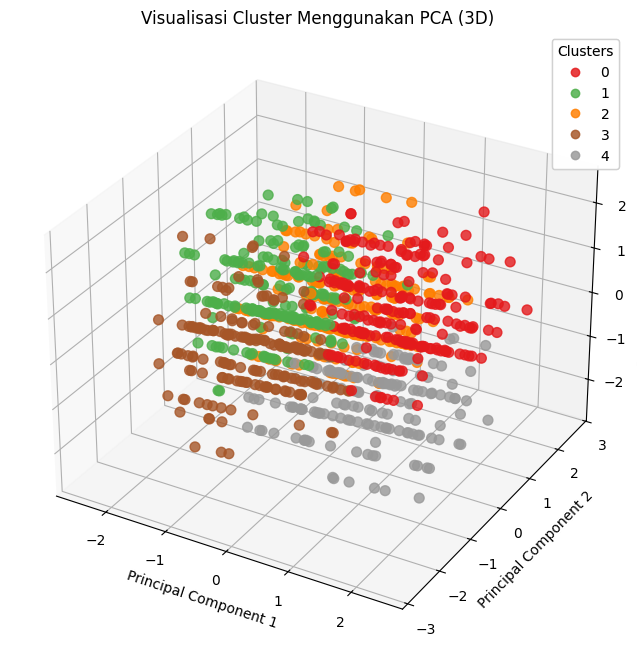

In [51]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# 1. Tarik data X yang sudah di-scale, tapi kali ini ambil 3 komponen utama
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X)

# 2. Buat DataFrame baru untuk hasil PCA 3D
df_pca_3d = pd.DataFrame(X_pca_3d, columns=['PC1', 'PC2', 'PC3'])

# 3. Tarik kolom 'Cluster' dari dataframe asli
df_pca_3d['Cluster'] = df['Cluster'].values

# --- VISUALISASI 3D ---
fig = plt.figure(figsize=(10, 8))

# Tambahkan projection='3d' untuk membuat sumbu 3D
ax = fig.add_subplot(111, projection='3d')

# Gunakan scatter plot 3D
# Kita gunakan colormap (cmap) untuk membedakan warna setiap cluster
scatter = ax.scatter(df_pca_3d['PC1'],
                     df_pca_3d['PC2'],
                     df_pca_3d['PC3'],
                     c=df_pca_3d['Cluster'],
                     cmap='Set1',
                     s=50,       # ukuran titik
                     alpha=0.8)  # transparansi titik

# Atur label sumbu
ax.set_title('Visualisasi Cluster Menggunakan PCA (3D)')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

# Tambahkan legend agar jelas warna apa untuk cluster yang mana
legend = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend)

plt.show()

## UNTUK SHAP

In [52]:
# 1. Buat duplikat dari df_scaled agar DataFrame yang lama tetap utuh
df_scaled_cluster = df_scaled.copy()

# 2. Tambahkan kolom 'Cluster' dari dataframe asli (df) ke DataFrame yang baru
# Menggunakan .values sangat disarankan untuk menghindari error jika ada perbedaan index
df_scaled_cluster['Cluster'] = df['Cluster'].values

# Tampilkan hasilnya untuk memastikan
print("=== DATAFRAME SCALED + CLUSTER ===")
display(df_scaled_cluster.head())

=== DATAFRAME SCALED + CLUSTER ===


,PerformanceScore,JobSatisfaction,YearsAtCompany,MonthlyIncome,Cluster
0,-1.889822,-0.937548,-0.168593,0.277243,4
1,-1.889822,-0.937548,-0.168593,-0.692401,4
2,1.889822,-1.867656,0.950699,0.397299,0
3,0.000000,-0.937548,-1.008062,-0.145624,3
4,0.000000,-0.007441,1.370433,-0.114646,2


# CLUSTER 3 dan 4

RF Accuracy (Cluster 3): 0.9800

Mean |SHAP| per fitur:
JobSatisfaction     0.2507
YearsAtCompany      0.0858
MonthlyIncome       0.0405
PerformanceScore    0.0179
dtype: float64


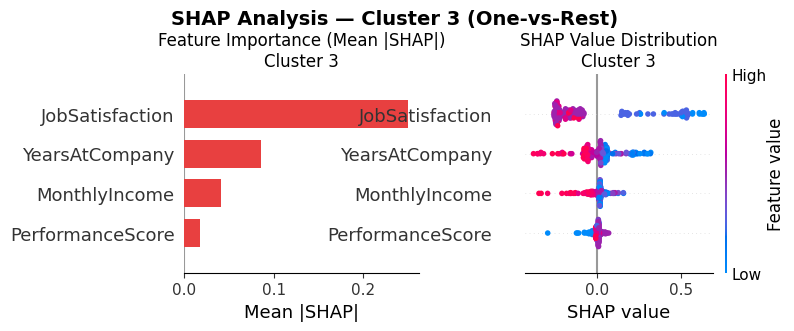

RF Accuracy (Cluster 4): 0.9800

Mean |SHAP| per fitur:
PerformanceScore    0.2131
YearsAtCompany      0.0615
MonthlyIncome       0.0495
JobSatisfaction     0.0100
dtype: float64


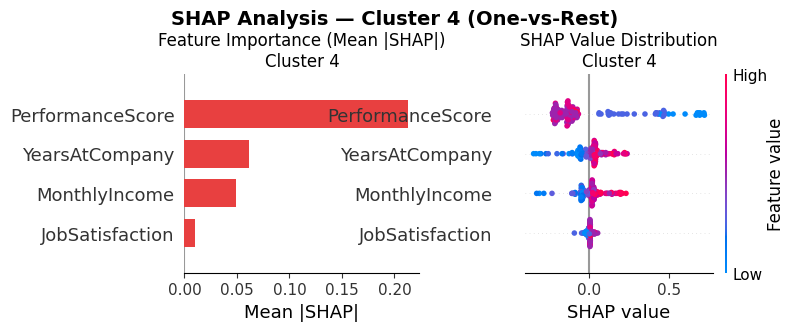

In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import shap
import numpy as np
import matplotlib.pyplot as plt

def shap_cluster(df_scaled_cluster, feats, c):
    """One-vs-Rest RF + SHAP untuk cluster c, dual plot bar + beeswarm."""
    d = df_scaled_cluster.copy()
    d[f'Is_Cluster_{c}'] = (d['Cluster'] == c).astype(int)

    X_c = d[feats]
    y_c = d[f'Is_Cluster_{c}']

    X_train, X_test, y_train, y_test = train_test_split(
        X_c, y_c, test_size=0.2, random_state=42, stratify=y_c)

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    print(f"RF Accuracy (Cluster {c}): {rf.score(X_test, y_test):.4f}")

    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_test)

    # Penanganan struktur array SHAP agar bebas error
    if isinstance(shap_values, list):
        sv = shap_values[1]              # index 1 = kelas 'Is_Cluster_c'
    elif shap_values.ndim == 3:
        sv = shap_values[:, :, 1]
    else:
        sv = shap_values

    mean_shap = pd.Series(np.abs(sv).mean(axis=0), index=feats).sort_values(ascending=False)
    print("\nMean |SHAP| per fitur:")
    print(mean_shap.round(4))

    # Dual plot: bar + beeswarm
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'SHAP Analysis — Cluster {c} (One-vs-Rest)',
                 fontsize=14, fontweight='bold', y=1.03)

    plt.sca(axes[0])
    shap.summary_plot(sv, X_test, plot_type='bar', show=False, color='#E84040')
    axes[0].set_title(f'Feature Importance (Mean |SHAP|)\nCluster {c}', fontsize=12)
    axes[0].set_xlabel('Mean |SHAP|')

    plt.sca(axes[1])
    shap.summary_plot(sv, X_test, show=False)
    axes[1].set_title(f'SHAP Value Distribution\nCluster {c}', fontsize=12)
    axes[1].set_xlabel('SHAP value')

    plt.subplots_adjust(top=0.82, bottom=0.18, wspace=0.45)
    plt.show()

    return rf, sv, mean_shap

rf_c3, sv_c3, mean_shap_c3 = shap_cluster(df_scaled_cluster, feats, 3)
rf_c4, sv_c4, mean_shap_c4 = shap_cluster(df_scaled_cluster, feats, 4)

Kesimpulan Cluster 3: segmen New, Low Engagement — karyawan dengan masa kerja pendek-menengah dan kepuasan kerja sangat rendah, meski performa dan income masih normal. Ini adalah cluster dengan risiko resign tertinggi karena kombinasi disengagement + belum ada ikatan senioritas. Prioritas HR: intervensi engagement segera (stay interview, one-on-one dengan manajer, evaluasi beban kerja dan job-fit) sebelum performa ikut turun atau karyawan resign. Berbeda dengan Cluster 2 yang solusinya kompensasi, solusi Cluster 3 ada di kualitas pengalaman kerja sehari-hari.

Kesimpulan Cluster 4: segmen Senior Low Performer — karyawan tenure panjang dengan kompensasi layak dan kepuasan normal, tetapi performa jauh di bawah standar. Berbeda dengan Cluster 3 (masalah engagement) dan Cluster 2 (masalah kompensasi), masalah Cluster 4 adalah produktivitas. Prioritas HR: Performance Improvement Plan (PIP) yang terstruktur, assessment ulang job-fit (mungkin skill-nya sudah tidak relevan dengan tuntutan role), reskilling/upskilling terarah, dan evaluasi apakah ada faktor sistemik (manajer, proses, tools) yang menahan performa kelompok senior ini.

## Cluster 1

**Profil Cluster 1:** YearsAtCompany rendah (4.03 tahun), JobSatisfaction tertinggi (3.63), MonthlyIncome menengah (11.967), PerformanceScore menengah (3.18).

Interpretasi: karyawan **baru dengan engagement tinggi** — baru bergabung tapi sudah cukup puas dengan pekerjaannya. SHAP di bawah akan menunjukkan fitur mana yang paling membedakan cluster ini dari cluster lainnya.

In [54]:
# One-vs-Rest: 1 jika Cluster 1, 0 jika bukan
df_rf_c1 = df_scaled_cluster.copy()
df_rf_c1['Is_Cluster_1'] = (df_rf_c1['Cluster'] == 1).astype(int)

X_rf_c1 = df_rf_c1[feats]
y_rf_c1 = df_rf_c1['Is_Cluster_1']

X_train_c1, X_test_c1, y_train_c1, y_test_c1 = train_test_split(
    X_rf_c1, y_rf_c1, test_size=0.2, random_state=42, stratify=y_rf_c1)

rf_c1 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_c1.fit(X_train_c1, y_train_c1)
print(f"RF Accuracy (Cluster 1): {rf_c1.score(X_test_c1, y_test_c1):.4f}")

explainer_c1 = shap.TreeExplainer(rf_c1)
shap_values_c1 = explainer_c1.shap_values(X_test_c1)
sv_c1 = shap_values_c1[:, :, 1]  # ambil class=1 (is cluster 1)

mean_shap_c1 = pd.Series(np.abs(sv_c1).mean(axis=0), index=feats).sort_values(ascending=False)
print("\nMean |SHAP| per fitur:")
print(mean_shap_c1.round(4))

RF Accuracy (Cluster 1): 1.0000

Mean |SHAP| per fitur:
YearsAtCompany      0.2464
JobSatisfaction     0.1243
MonthlyIncome       0.0355
PerformanceScore    0.0229
dtype: float64


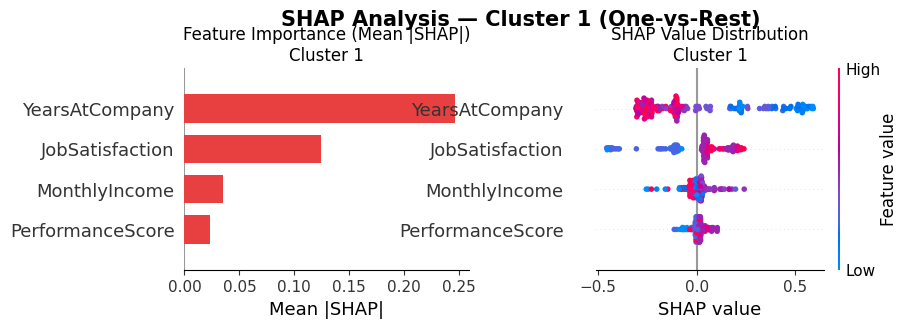

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    'SHAP Analysis — Cluster 1 (One-vs-Rest)',
    fontsize=15,
    fontweight='bold',
    y=1.02
)

# Bar plot
plt.sca(axes[0])
shap.summary_plot(
    sv_c1,
    X_test_c1,
    plot_type='bar',
    color='#E84040',
    show=False
)
axes[0].set_title('Feature Importance (Mean |SHAP|)\nCluster 1', fontsize=12)
axes[0].set_xlabel('Mean |SHAP|')

# Beeswarm plot
plt.sca(axes[1])
shap.summary_plot(
    sv_c1,
    X_test_c1,
    show=False
)
axes[1].set_title('SHAP Value Distribution\nCluster 1', fontsize=12)
axes[1].set_xlabel('SHAP value')

# Atur jarak manual
fig.subplots_adjust(
    top=0.83,
    bottom=0.18,
    left=0.08,
    right=0.95,
    wspace=0.45
)

plt.show()

### Analisis SHAP Cluster 1

**Fitur paling dominan: `YearsAtCompany` (0.2464)**
Kontribusi terbesar yang membedakan Cluster 1 dari cluster lain adalah masa kerja yang **rendah**. Nilai SHAP negatif di beeswarm (warna biru = nilai feature rendah, SHAP positif ke kanan = mendorong masuk Cluster 1) mengonfirmasi bahwa **masa kerja pendek** adalah karakteristik utama cluster ini.

**Fitur kedua: `JobSatisfaction` (0.1243)**
Satisfaction yang **tinggi** menjadi pembeda kedua — titik merah (nilai tinggi) mengarah ke SHAP positif, artinya satisfaction tinggi mendorong karyawan masuk ke Cluster 1. Ini yang membedakan Cluster 1 dari Cluster 3 (yang juga junior tapi satisfaction rendah).

**Fitur kurang dominan: `MonthlyIncome` & `PerformanceScore`**
Kedua fitur ini kontribusinya kecil (0.0355 dan 0.0229), artinya income dan performa bukan pembeda utama — cluster ini bisa punya income dan performa beragam, yang menyatukannya adalah kombinasi **baru + puas**.

> **Kesimpulan Cluster 1:** segmen *New High Engagement* — karyawan dengan masa kerja pendek (<4 tahun) dan kepuasan tinggi. Prioritas HR: jaga momentum engagement ini dengan onboarding yang kuat dan jalur pengembangan yang jelas supaya satisfaction tidak drop seiring waktu.

## Cluster 2

**Profil Cluster 2:** YearsAtCompany tinggi (16.29 tahun), MonthlyIncome terendah (5.455), JobSatisfaction menengah-tinggi (3.48), PerformanceScore menengah (3.26).

Interpretasi: karyawan **senior dengan gaji rendah** — sudah lama di perusahaan tapi kompensasinya tidak mencerminkan senioritas. SHAP akan menunjukkan seberapa kuat MonthlyIncome mendominasi pembentukan cluster ini.

In [56]:
# One-vs-Rest: 1 jika Cluster 2, 0 jika bukan
df_rf_c2 = df_scaled_cluster.copy()
df_rf_c2['Is_Cluster_2'] = (df_rf_c2['Cluster'] == 2).astype(int)

X_rf_c2 = df_rf_c2[feats]
y_rf_c2 = df_rf_c2['Is_Cluster_2']

X_train_c2, X_test_c2, y_train_c2, y_test_c2 = train_test_split(
    X_rf_c2, y_rf_c2, test_size=0.2, random_state=42, stratify=y_rf_c2)

rf_c2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_c2.fit(X_train_c2, y_train_c2)
print(f"RF Accuracy (Cluster 2): {rf_c2.score(X_test_c2, y_test_c2):.4f}")

explainer_c2 = shap.TreeExplainer(rf_c2)
shap_values_c2 = explainer_c2.shap_values(X_test_c2)
sv_c2 = shap_values_c2[:, :, 1]  # ambil class=1 (is cluster 2)

mean_shap_c2 = pd.Series(np.abs(sv_c2).mean(axis=0), index=feats).sort_values(ascending=False)
print("\nMean |SHAP| per fitur:")
print(mean_shap_c2.round(4))

RF Accuracy (Cluster 2): 0.9850

Mean |SHAP| per fitur:
MonthlyIncome       0.2183
YearsAtCompany      0.1245
JobSatisfaction     0.0766
PerformanceScore    0.0537
dtype: float64


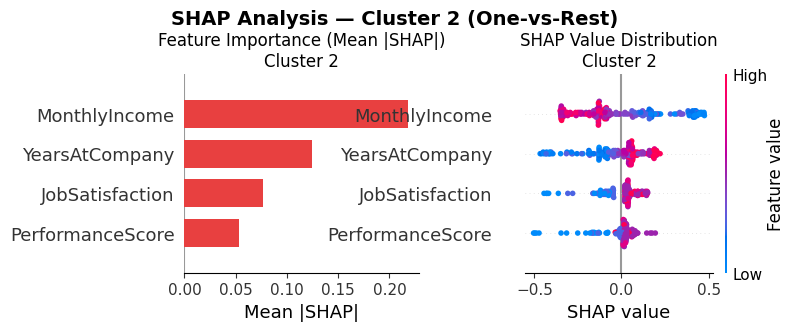

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('SHAP Analysis — Cluster 2 (One-vs-Rest)',
             fontsize=14, fontweight='bold', y=1.03)

plt.sca(axes[0])
shap.summary_plot(
    sv_c2,
    X_test_c2,
    plot_type='bar',
    show=False,
    color='#E84040'
)
axes[0].set_title('Feature Importance (Mean |SHAP|)\nCluster 2', fontsize=12)
axes[0].set_xlabel('Mean |SHAP|')

plt.sca(axes[1])
shap.summary_plot(
    sv_c2,
    X_test_c2,
    show=False
)
axes[1].set_title('SHAP Value Distribution\nCluster 2', fontsize=12)
axes[1].set_xlabel('SHAP value')

plt.subplots_adjust(
    top=0.82,
    bottom=0.18,
    wspace=0.45
)

plt.show()

### Analisis SHAP Cluster 2

**Fitur paling dominan: `MonthlyIncome` (0.2183)**
Jauh melampaui fitur lain — `MonthlyIncome` yang **sangat rendah** adalah pembeda utama Cluster 2. Di beeswarm, titik biru (income rendah) berkumpul di sisi positif SHAP, artinya income rendah adalah yang paling kuat mendorong karyawan masuk cluster ini.

**Fitur kedua: `YearsAtCompany` (0.1245)**
Masa kerja **panjang** jadi pembeda kedua. Kombinasi income rendah + tenure panjang ini yang membentuk narasi "sudah lama tapi belum dihargai secara kompensasi."

**Fitur ketiga: `JobSatisfaction` (0.0766)**
Menariknya satisfaction-nya masih menengah-tinggi meski income rendah — cluster ini relatif masih bisa menerima kondisinya. Tapi kontribusi SHAP-nya lebih kecil, artinya satisfaction bukan pembeda yang tegas.

**Fitur paling lemah: `PerformanceScore` (0.0537)**
Performa tidak terlalu membedakan cluster ini dari yang lain — performanya rata-rata dan tidak menjadi ciri khas.

> **Kesimpulan Cluster 2:** segmen *Loyal but Underpaid* — karyawan senior (>16 tahun) dengan kompensasi yang tidak sepadan masa kerjanya. SHAP mengonfirmasi bahwa `MonthlyIncome` adalah faktor pembeda terkuat, bukan satisfaction atau performa. Prioritas HR: review kompensasi untuk segmen ini sebelum satisfaction mulai turun dan potensi turnover meningkat.

# **Cluster 0**

## **Cluster 0 — Established High Performer Group**

**Profil Cluster 0:** YearsAtCompany tinggi (16.88 tahun), MonthlyIncome tertinggi (18.339), JobSatisfaction menengah (3.04), PerformanceScore tinggi (3.71).

Interpretasi: Cluster 0 merepresentasikan karyawan **senior, berpenghasilan tinggi, dan memiliki performa kerja tinggi**. Kelompok ini dapat dianggap sebagai karyawan bernilai tinggi bagi perusahaan karena memiliki masa kerja panjang dan kontribusi performa yang kuat.

Namun, JobSatisfaction pada cluster ini tidak setinggi performa dan pendapatannya. Hal ini menunjukkan bahwa meskipun karyawan dalam cluster ini tergolong mapan, HR tetap perlu menjaga engagement dan kepuasan kerja agar risiko penurunan motivasi atau turnover pada karyawan bernilai tinggi dapat diminimalkan.

SHAP akan digunakan untuk melihat seberapa kuat MonthlyIncome, YearsAtCompany, dan PerformanceScore dalam membedakan Cluster 0 dari cluster lainnya.

In [58]:
# @title
# One-vs-Rest: 1 jika Cluster 0, 0 jika bukan
df_rf_c0 = df_scaled_cluster.copy()
df_rf_c0['Is_Cluster_0'] = (df_rf_c0['Cluster'] == 0).astype(int)

X_rf_c0 = df_rf_c0[feats]
y_rf_c0 = df_rf_c0['Is_Cluster_0']

X_train_c0, X_test_c0, y_train_c0, y_test_c0 = train_test_split(
    X_rf_c0, y_rf_c0, test_size=0.2, random_state=42, stratify=y_rf_c0)

rf_c0 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_c0.fit(X_train_c0, y_train_c0)
print(f"RF Accuracy (Cluster 0): {rf_c0.score(X_test_c0, y_test_c0):.4f}")

explainer_c0 = shap.TreeExplainer(rf_c0)
shap_values_c0 = explainer_c0.shap_values(X_test_c0)
sv_c0 = shap_values_c0[:, :, 1]  # ambil class=1 (is cluster 0)

mean_shap_c0 = pd.Series(np.abs(sv_c0).mean(axis=0), index=feats).sort_values(ascending=False)
print("\nMean |SHAP| per fitur:")
print(mean_shap_c0.round(4))

RF Accuracy (Cluster 0): 0.9800

Mean |SHAP| per fitur:
MonthlyIncome       0.1935
YearsAtCompany      0.1320
PerformanceScore    0.1195
JobSatisfaction     0.0171
dtype: float64


### Analisis SHAP Cluster 0

**Fitur paling dominan: `MonthlyIncome` (0.1935)**  
Kontribusi terbesar yang membedakan Cluster 0 dari cluster lain adalah `MonthlyIncome`. Hal ini menunjukkan bahwa pendapatan tinggi merupakan karakteristik utama Cluster 0.

**Fitur kedua: `YearsAtCompany` (0.1320)**  
Masa kerja panjang menjadi pembeda kedua. Artinya, Cluster 0 banyak diisi oleh karyawan yang sudah lama berada di perusahaan.

**Fitur ketiga: `PerformanceScore` (0.1195)**  
PerformanceScore juga menjadi pembeda penting. Ini menunjukkan bahwa Cluster 0 tidak hanya berisi karyawan senior dan berpenghasilan tinggi, tetapi juga memiliki performa kerja yang relatif tinggi.

**Fitur paling lemah: `JobSatisfaction` (0.0171)**  
JobSatisfaction memiliki kontribusi paling kecil dalam membedakan Cluster 0. Artinya, kepuasan kerja bukan faktor utama pembentuk cluster ini. Namun, karena Cluster 0 merupakan kelompok bernilai tinggi, HR tetap perlu menjaga engagement dan satisfaction kelompok ini.

> **Kesimpulan Cluster 0:** segmen *Established High Performer Group* — karyawan senior dengan pendapatan tinggi dan performa kerja tinggi. Kelompok ini bernilai strategis bagi perusahaan, sehingga perlu dijaga melalui recognition, career development, leadership pathway, dan retention conversation.

### **Visual Interpretation — Cluster 0**

Berdasarkan visualisasi SHAP, fitur yang paling menonjol dalam membedakan Cluster 0 adalah **MonthlyIncome**, diikuti oleh **YearsAtCompany** dan **PerformanceScore**.

Hal ini memperkuat interpretasi bahwa Cluster 0 merupakan kelompok karyawan yang memiliki karakteristik utama berupa pendapatan tinggi, masa kerja panjang, dan performa kerja tinggi.

Dengan demikian, Cluster 0 dapat diposisikan sebagai **Established High Performer Group**. Kelompok ini penting untuk dipertahankan karena memiliki nilai strategis bagi perusahaan.

Namun, karena JobSatisfaction bukan fitur dominan dan berada pada level menengah, HR tetap perlu menjaga engagement kelompok ini melalui recognition, career development, leadership pathway, dan retention conversation.

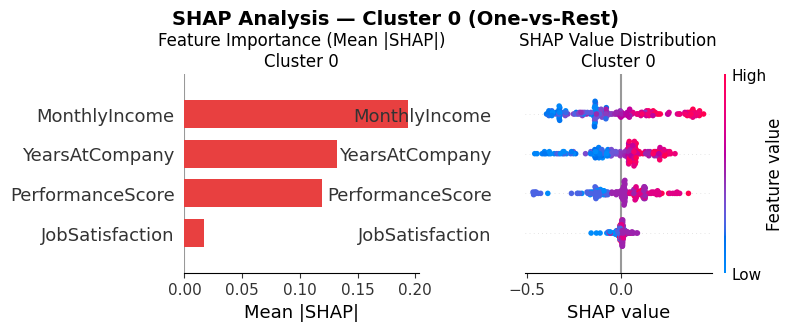

In [59]:
# @title
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('SHAP Analysis — Cluster 0 (One-vs-Rest)',
             fontsize=14, fontweight='bold', y=1.03)

plt.sca(axes[0])
shap.summary_plot(
    sv_c0,
    X_test_c0,
    plot_type='bar',
    show=False,
    color='#E84040'
)
axes[0].set_title('Feature Importance (Mean |SHAP|)\nCluster 0', fontsize=12)
axes[0].set_xlabel('Mean |SHAP|')

plt.sca(axes[1])
shap.summary_plot(
    sv_c0,
    X_test_c0,
    show=False
)
axes[1].set_title('SHAP Value Distribution\nCluster 0', fontsize=12)
axes[1].set_xlabel('SHAP value')

plt.subplots_adjust(
    top=0.82,
    bottom=0.18,
    wspace=0.45
)

plt.show()

### **Conclusion — Cluster 0**

Cluster 0 dapat diinterpretasikan sebagai **Established High Performer Group**, yaitu kelompok karyawan senior dengan pendapatan tinggi dan performa kerja tinggi.

Secara bisnis, cluster ini merupakan kelompok bernilai tinggi bagi perusahaan karena memiliki pengalaman, kontribusi, dan kompensasi yang relatif kuat. Oleh karena itu, strategi HR untuk Cluster 0 sebaiknya tidak hanya berfokus pada kompensasi, tetapi juga pada pengembangan karier, recognition, dan engagement monitoring.

Rekomendasi utama untuk Cluster 0:

1. Memberikan recognition atau penghargaan atas kontribusi karyawan.
2. Menyediakan career development dan leadership development.
3. Melakukan retention conversation secara berkala.
4. Menjaga engagement agar JobSatisfaction tidak menurun.
5. Mempertimbangkan kelompok ini dalam succession planning.

Interpretasi ini bersifat exploratory. Random Forest dan SHAP digunakan sebagai alat bantu interpretasi cluster, bukan sebagai model prediksi employee retention.

## Profil

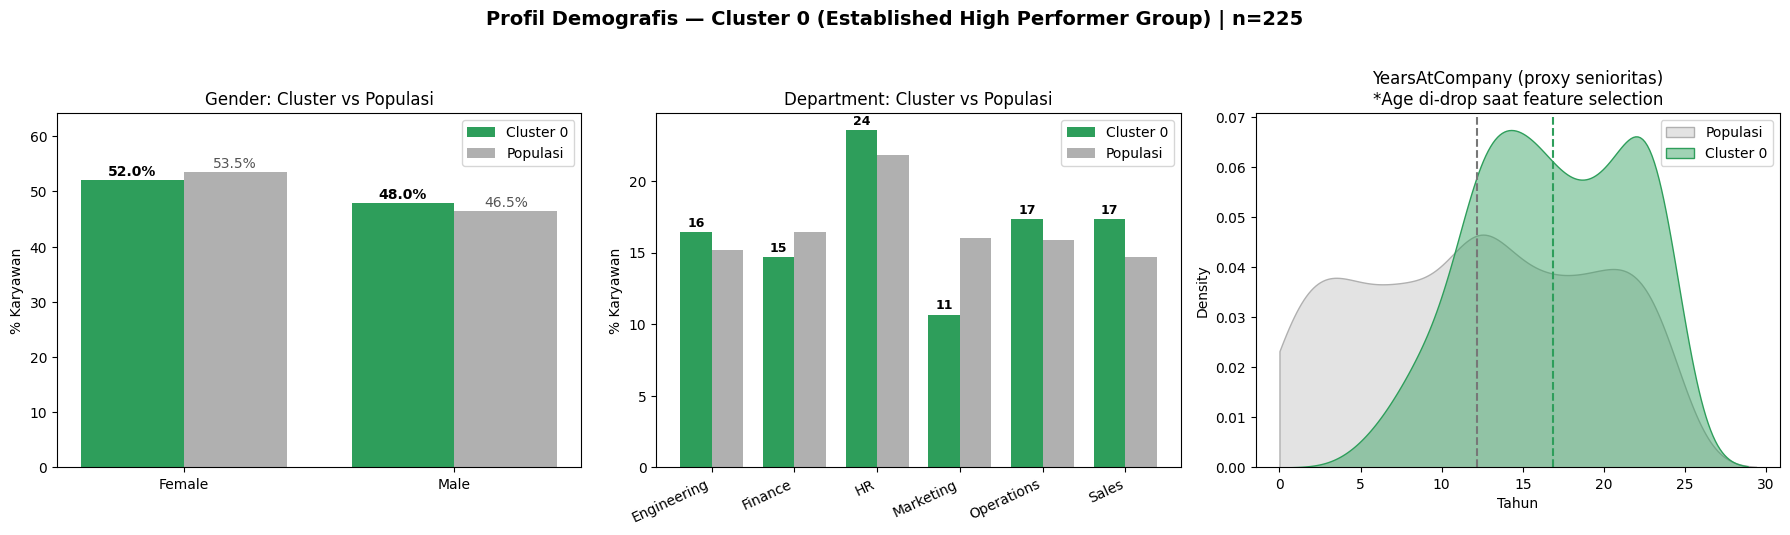

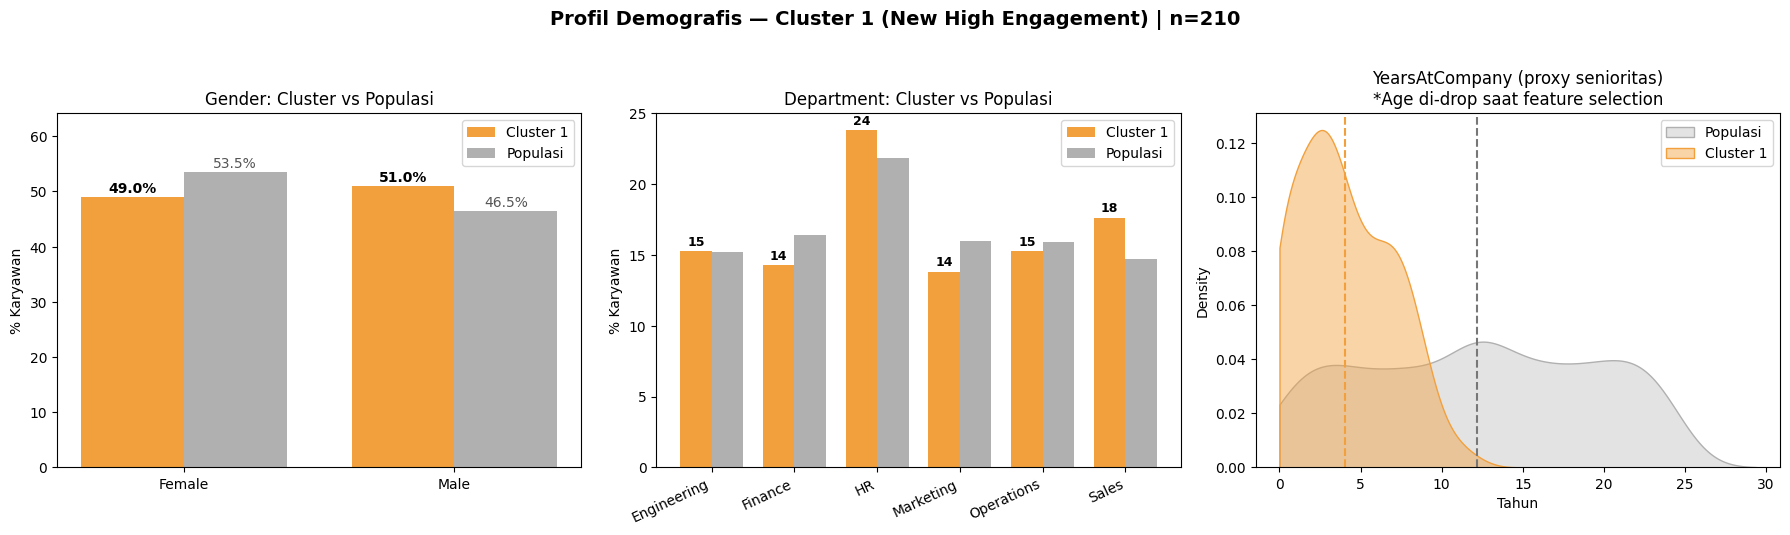

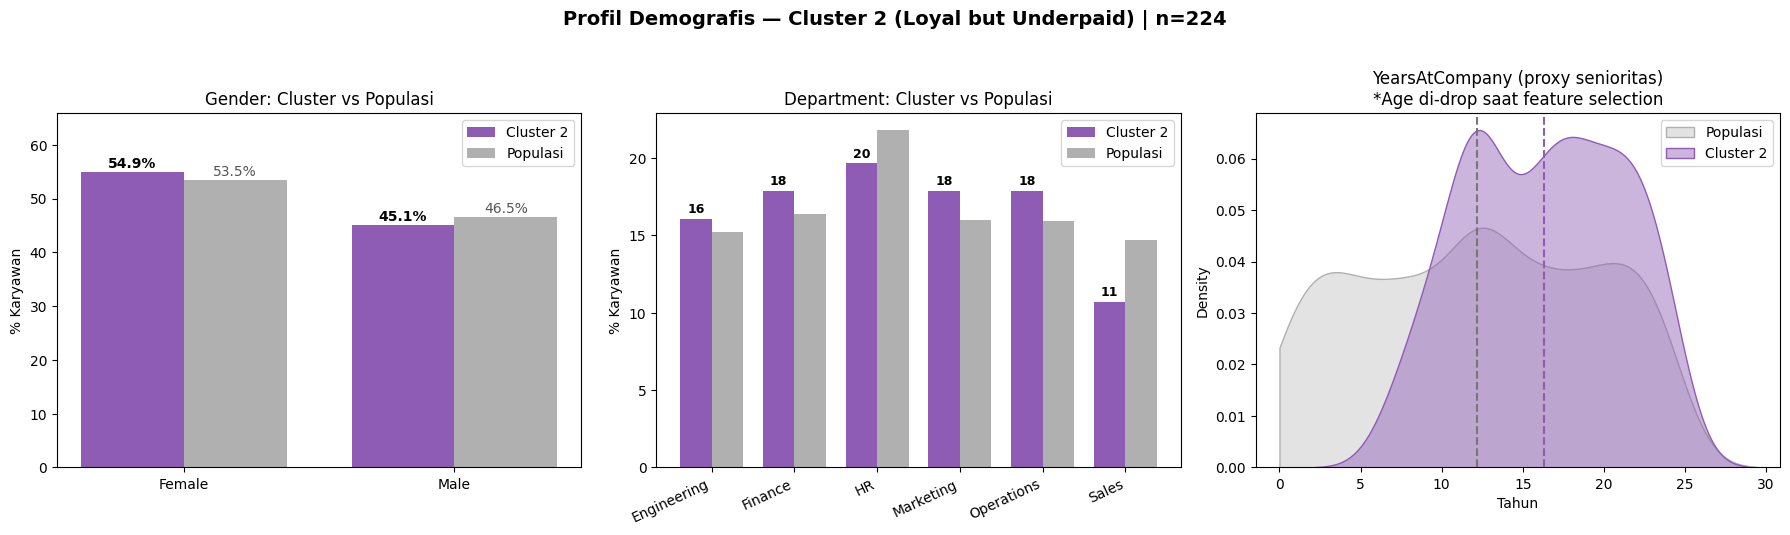

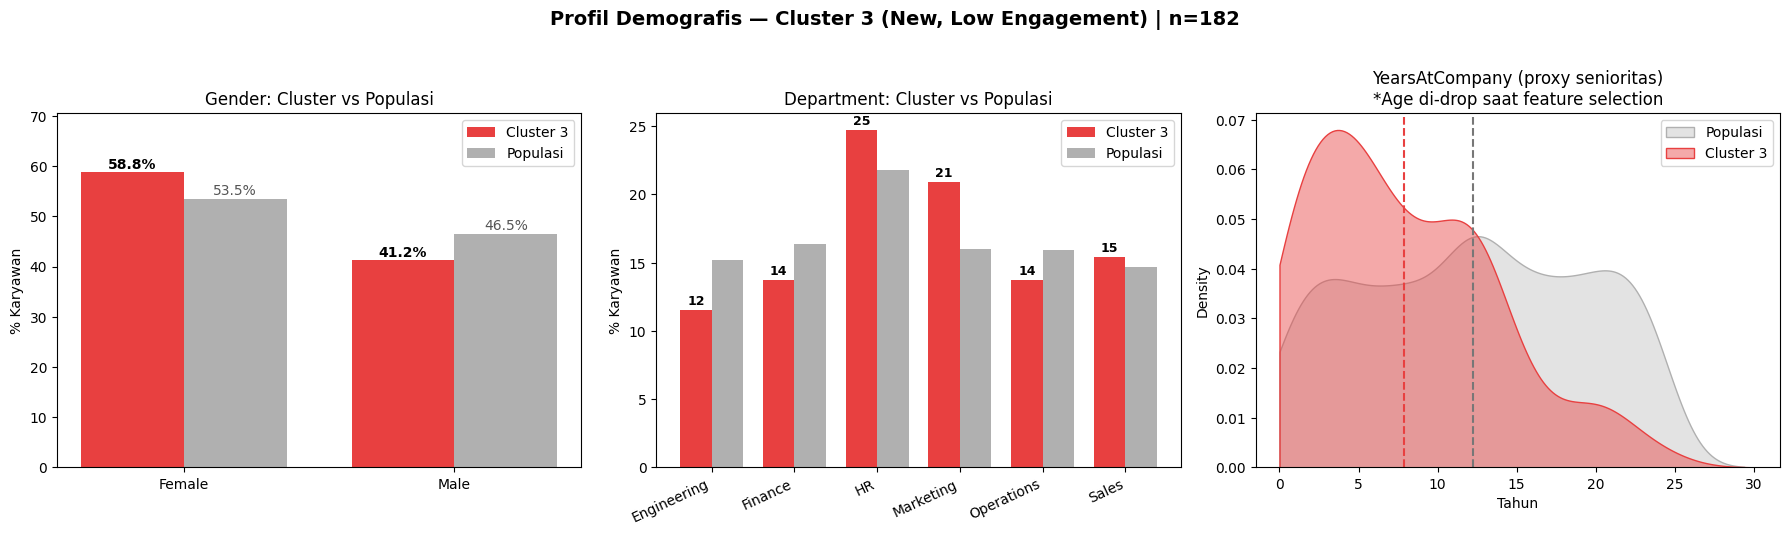

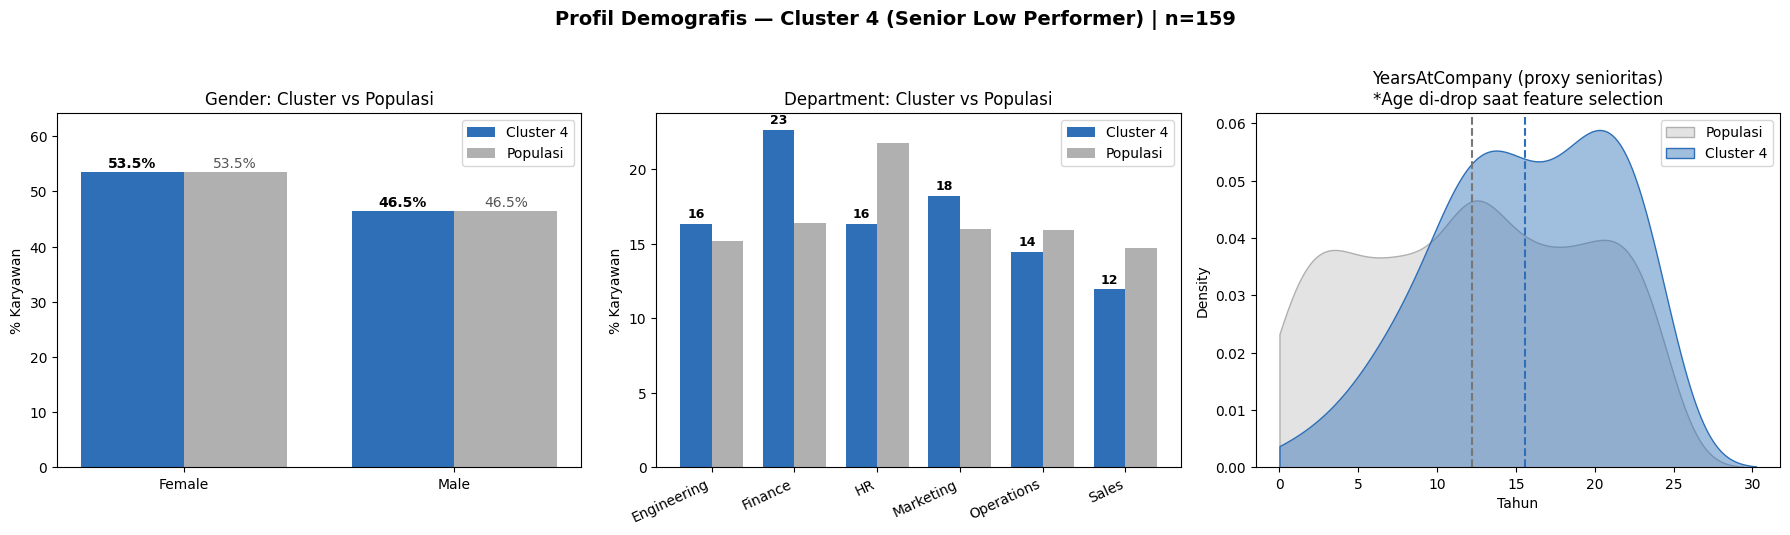

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dept_order = ['Engineering','Finance','HR','Marketing','Operations','Sales']
CLUSTER_COLOR = {
    0: '#2E9E5B',   # hijau  — Established High Performer Group
    1: '#F2A03D',   # oranye — New High Engagement
    2: '#8E5BB5',   # ungu   — Loyal but Underpaid
    3: '#E84040',   # merah  — New, Low Engagement
    4: '#2E6FB7',   # biru   — Senior Low Performer
}
POP_COLOR = '#B0B0B0'
NAMES = {
    0: 'Established High Performer Group',
    1: 'New High Engagement',
    2: 'Loyal but Underpaid',
    3: 'New, Low Engagement',
    4: 'Senior Low Performer',
}

def demografi_plot(df, c):
    """df harus punya kolom Cluster, Gender, Department, YearsAtCompany."""
    sub = df[df['Cluster'] == c]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
    fig.suptitle(f'Profil Demografis — Cluster {c} ({NAMES[c]}) | n={len(sub)}',
                 fontsize=14, fontweight='bold', y=1.02)

    # Gender: cluster vs populasi
    g_c = sub['Gender'].value_counts(normalize=True).reindex(['Female','Male'])*100
    g_p = df['Gender'].value_counts(normalize=True).reindex(['Female','Male'])*100
    x = np.arange(2); w = 0.38
    axes[0].bar(x-w/2, g_c, w, label=f'Cluster {c}', color=CLUSTER_COLOR[c])
    axes[0].bar(x+w/2, g_p, w, label='Populasi', color=POP_COLOR)
    for i,(vc,vp) in enumerate(zip(g_c, g_p)):
        axes[0].text(i-w/2, vc+0.8, f'{vc:.1f}%', ha='center', fontweight='bold')
        axes[0].text(i+w/2, vp+0.8, f'{vp:.1f}%', ha='center', color='#555')
    axes[0].set_xticks(x); axes[0].set_xticklabels(['Female','Male'])
    axes[0].set_ylabel('% Karyawan'); axes[0].set_title('Gender: Cluster vs Populasi')
    axes[0].legend(); axes[0].set_ylim(0, max(g_c.max(), g_p.max())*1.2)

    # Department: cluster vs populasi
    d_c = sub['Department'].value_counts(normalize=True).reindex(dept_order)*100
    d_p = df['Department'].value_counts(normalize=True).reindex(dept_order)*100
    x = np.arange(len(dept_order))
    axes[1].bar(x-w/2, d_c, w, label=f'Cluster {c}', color=CLUSTER_COLOR[c])
    axes[1].bar(x+w/2, d_p, w, label='Populasi', color=POP_COLOR)
    for i, vc in enumerate(d_c):
        axes[1].text(i-w/2, vc+0.4, f'{vc:.0f}', ha='center', fontsize=9, fontweight='bold')
    axes[1].set_xticks(x); axes[1].set_xticklabels(dept_order, rotation=25, ha='right')
    axes[1].set_ylabel('% Karyawan'); axes[1].set_title('Department: Cluster vs Populasi')
    axes[1].legend()

    # YearsAtCompany sebagai proxy senioritas (Age di-drop saat feature selection)
    sns.kdeplot(df['YearsAtCompany'], ax=axes[2], color=POP_COLOR, fill=True,
                alpha=0.35, label='Populasi', clip=(0, None))
    sns.kdeplot(sub['YearsAtCompany'], ax=axes[2], color=CLUSTER_COLOR[c], fill=True,
                alpha=0.45, label=f'Cluster {c}', clip=(0, None))
    axes[2].axvline(sub['YearsAtCompany'].mean(), color=CLUSTER_COLOR[c], ls='--')
    axes[2].axvline(df['YearsAtCompany'].mean(), color='#777', ls='--')
    axes[2].set_title('YearsAtCompany (proxy senioritas)\n*Age di-drop saat feature selection')
    axes[2].set_xlabel('Tahun'); axes[2].legend()

    plt.tight_layout()
    plt.show()

for c in [0, 1, 2, 3, 4]:
    demografi_plot(df, c)

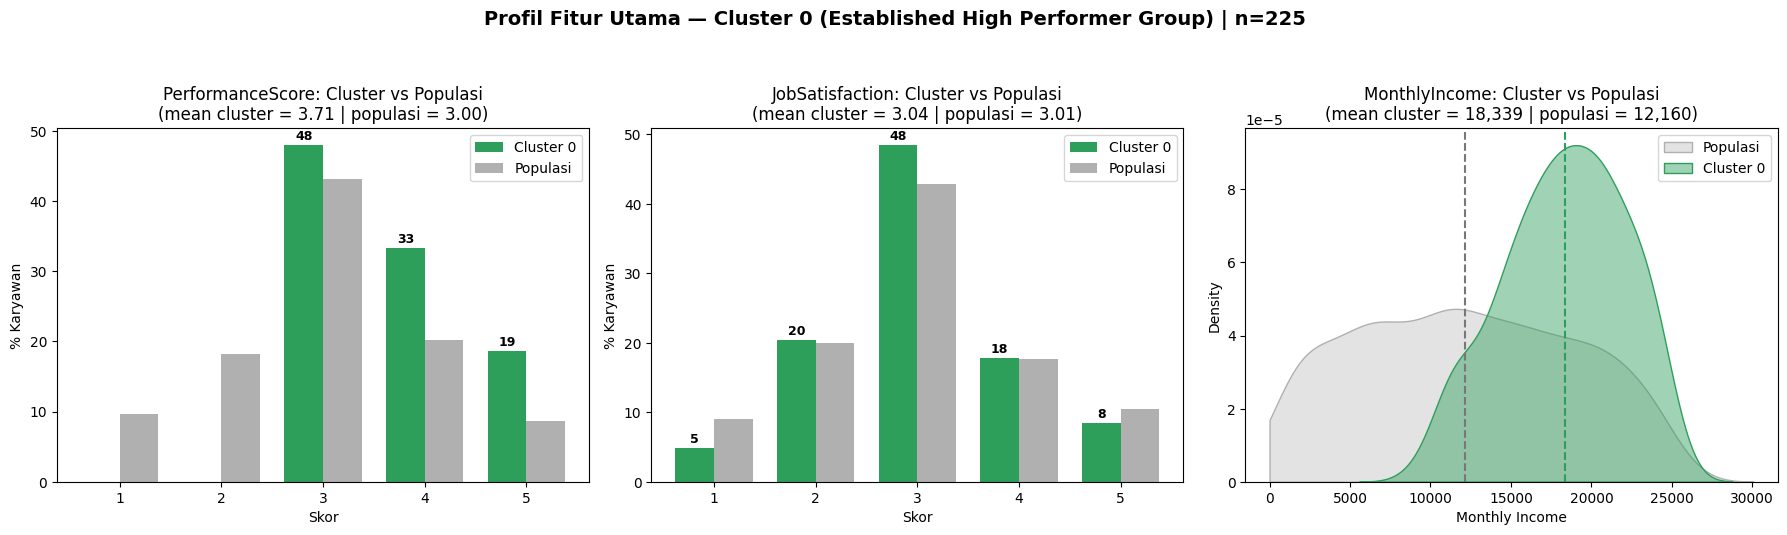

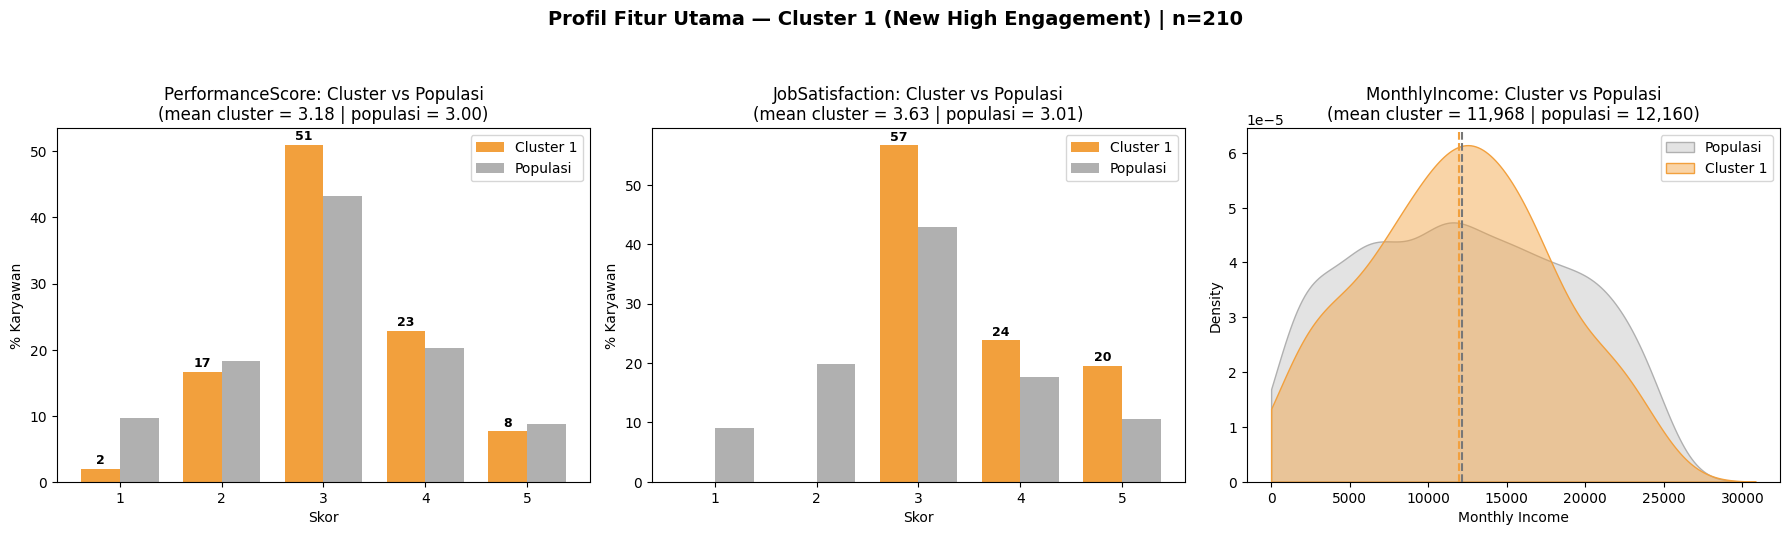

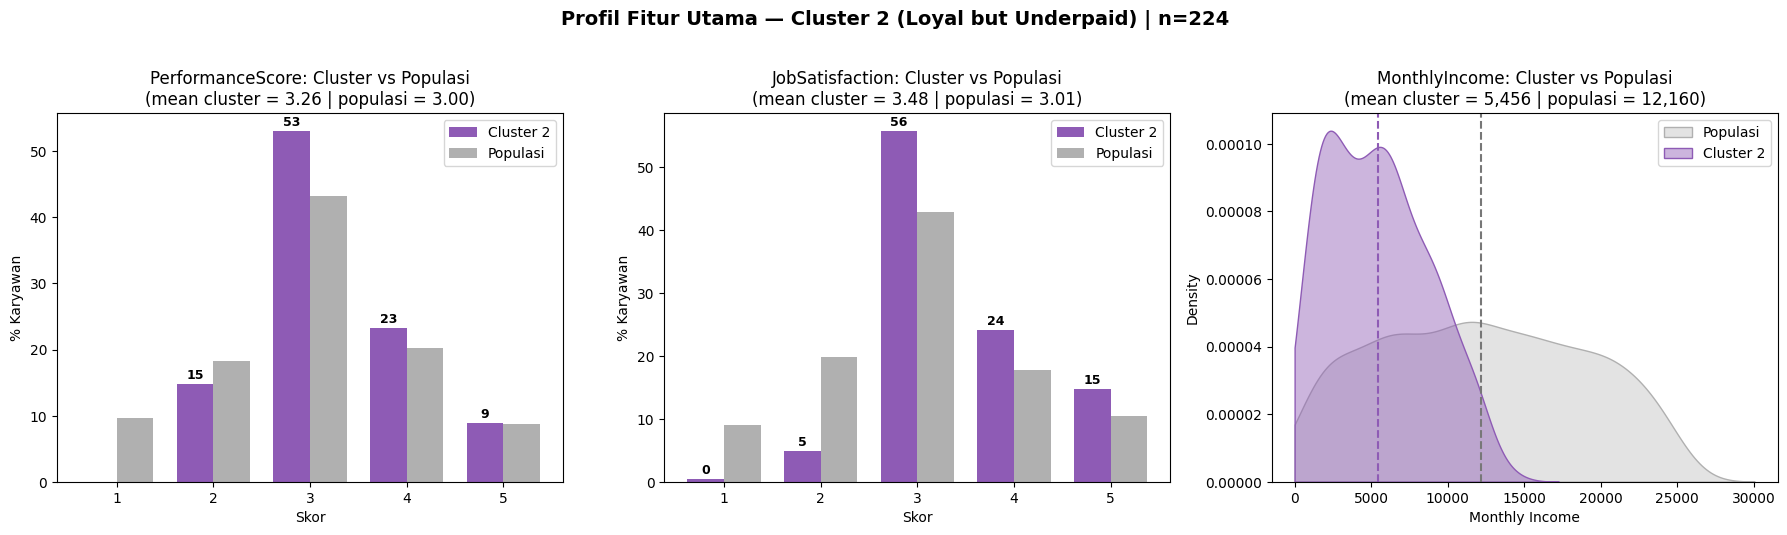

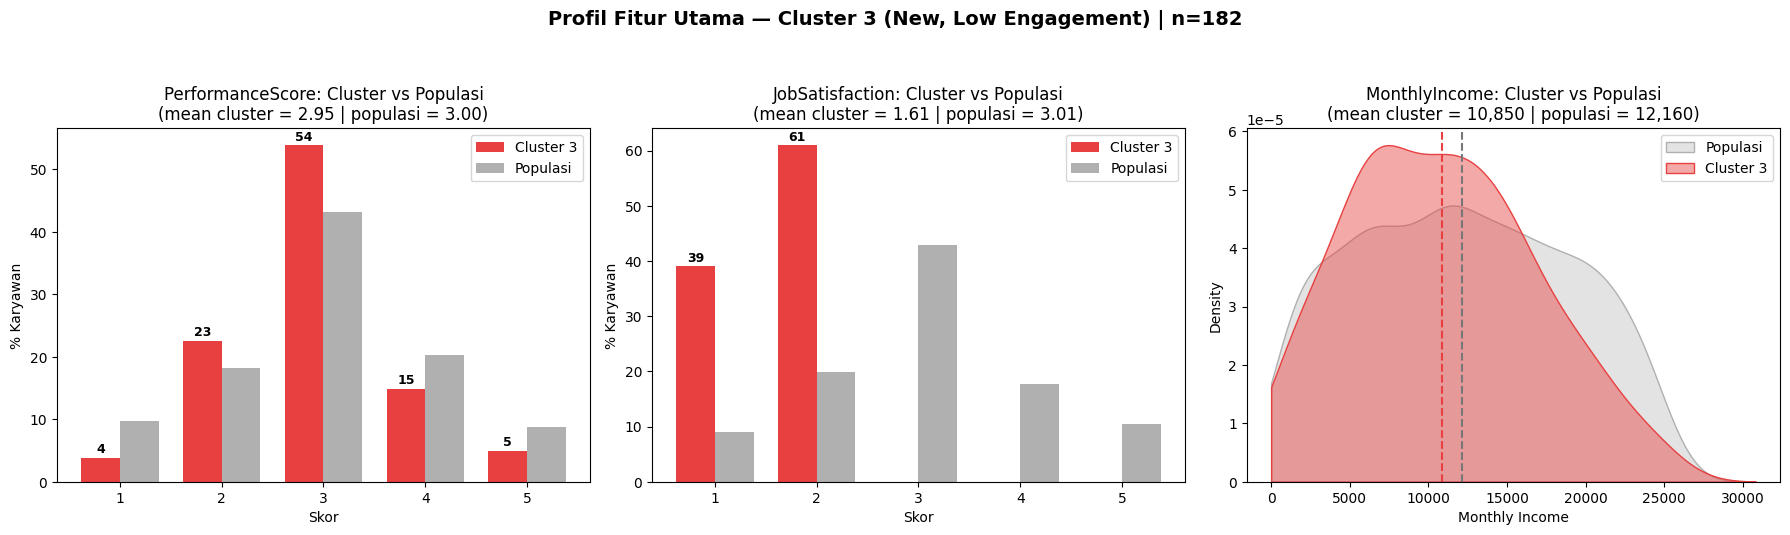

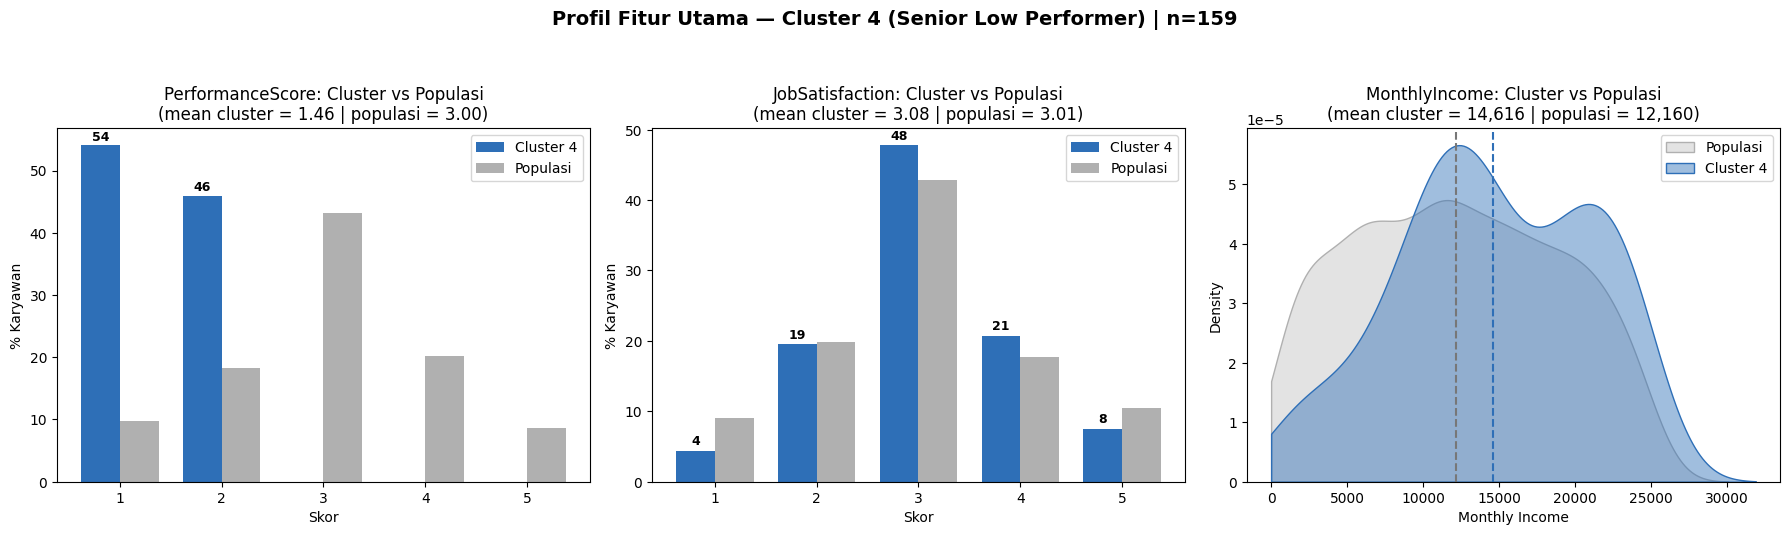

In [61]:
score_range = [1, 2, 3, 4, 5]

def fitur_plot(df, c):
    """Profil PerformanceScore, JobSatisfaction, MonthlyIncome per cluster vs populasi."""
    sub = df[df['Cluster'] == c]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
    fig.suptitle(f'Profil Fitur Utama — Cluster {c} ({NAMES[c]}) | n={len(sub)}',
                 fontsize=14, fontweight='bold', y=1.02)

    # PerformanceScore & JobSatisfaction: bar % per skor (diskrit 1-5)
    for ax, col in zip(axes[:2], ['PerformanceScore', 'JobSatisfaction']):
        f_c = sub[col].value_counts(normalize=True).reindex(score_range, fill_value=0)*100
        f_p = df[col].value_counts(normalize=True).reindex(score_range, fill_value=0)*100
        x = np.arange(len(score_range)); w = 0.38
        ax.bar(x-w/2, f_c, w, label=f'Cluster {c}', color=CLUSTER_COLOR[c])
        ax.bar(x+w/2, f_p, w, label='Populasi', color=POP_COLOR)
        for i, vc in enumerate(f_c):
            if vc > 0:
                ax.text(i-w/2, vc+0.8, f'{vc:.0f}', ha='center', fontsize=9, fontweight='bold')
        ax.set_xticks(x); ax.set_xticklabels(score_range)
        ax.set_xlabel('Skor'); ax.set_ylabel('% Karyawan')
        ax.set_title(f'{col}: Cluster vs Populasi\n'
                     f'(mean cluster = {sub[col].mean():.2f} | populasi = {df[col].mean():.2f})')
        ax.legend()

    # MonthlyIncome: KDE (kontinu)
    sns.kdeplot(df['MonthlyIncome'], ax=axes[2], color=POP_COLOR, fill=True,
                alpha=0.35, label='Populasi', clip=(0, None))
    sns.kdeplot(sub['MonthlyIncome'], ax=axes[2], color=CLUSTER_COLOR[c], fill=True,
                alpha=0.45, label=f'Cluster {c}', clip=(0, None))
    axes[2].axvline(sub['MonthlyIncome'].mean(), color=CLUSTER_COLOR[c], ls='--')
    axes[2].axvline(df['MonthlyIncome'].mean(), color='#777', ls='--')
    axes[2].set_title(f'MonthlyIncome: Cluster vs Populasi\n'
                      f'(mean cluster = {sub["MonthlyIncome"].mean():,.0f} | populasi = {df["MonthlyIncome"].mean():,.0f})')
    axes[2].set_xlabel('Monthly Income'); axes[2].legend()

    plt.tight_layout()
    plt.show()

for c in [0, 1, 2, 3, 4]:
    fitur_plot(df, c)

## Personalisasi Fitur Utama per Cluster (PerformanceScore, JobSatisfaction, MonthlyIncome, YearsAtCompany)

Karakteristik tiap cluster pada 4 fitur inti, dibandingkan dengan populasi:

| Cluster | PerformanceScore | JobSatisfaction | MonthlyIncome | YearsAtCompany | Karakter singkat |
|---|---|---|---|---|---|
| **0 — THE ESTABLISHED PERFORMER** | Mean 3.71 — **0% skor ≤2, 52% skor ≥4**, distribusi menumpuk di skor 4–5 | Mean 3.04 — netral, 25% skor ≤2 (sinyal yang perlu dipantau) | **Tertinggi** (mean 18.339), distribusi bergeser jauh ke kanan | **Paling senior** (mean 16.9 th, min 5 th) — **0% di bawah 5 tahun, 65% sudah ≥15 tahun** | Kontributor terbaik & termahal; satisfaction-nya biasa saja — risiko diam-diam jenuh |
| **1 — THE RISING STAR** | Mean 3.18 — mirip populasi, menyebar normal | Mean 3.63 — **0% skor ≤2, 43% skor ≥4** | Menengah (mean 11.968), mirip populasi | **Paling junior** (mean 4.0 th, max 12 th) — 60% di bawah 5 tahun, **0% yang ≥15 tahun** | Belum menonjol secara performa, tapi antusiasmenya paling sehat — modal berkembang |
| **2 — THE LOYAL PERFORMER** | Mean 3.26 — sedikit di atas populasi | Mean 3.48 — cukup tinggi, hanya 5% skor ≤2 | **Terendah ekstrem** (mean 5.456, kurang dari sepertiga Cluster 0), distribusi terisolasi di kiri | Senior (mean 16.3 th, min 7 th) — 61% sudah ≥15 tahun, setara Cluster 0 | Kerja oke, hati oke, dompet tidak — senioritasnya setara Cluster 0 tapi gajinya sepertiga; gap kompensasi adalah satu-satunya anomali |
| **3 — THE AT-RISK EMPLOYEE** | Mean 2.95 — mirip populasi, sedikit di bawah | Mean 1.61 — **100% karyawan punya skor ≤2, 0% skor ≥4**; hanya skor 1–2 yang terisi | Menengah-rendah (mean 10.850), mirip populasi | Junior-menengah (mean 7.9 th, median 7 th) — mayoritas (55%) di fase 5–15 tahun, hanya 12% yang ≥15 tahun | Satisfaction-nya bukan "rendah rata-rata" tapi **seluruh anggota tidak puas** — dan mereka ada di fase kritis evaluasi karier |
| **4 — THE DECLINING PERFORMER** | Mean 1.46 — **100% karyawan punya skor ≤2, 0% skor ≥4**; hanya skor 1–2 yang terisi | Mean 3.08 — normal, mirip populasi | Menengah-tinggi (mean 14.616, di atas populasi 12.160) | Senior (mean 15.6 th, median 16 th) — 57% sudah ≥15 tahun, hanya 4% di bawah 5 tahun | Kebalikan mutlak dari Cluster 3: puas, dibayar layak, dan sudah lama — tapi **semua anggotanya underperform** |

In [62]:
# 1. Duplikat data SEBELUM standarisasi
df_raw_cluster = df_clustering.copy()

# 2. Ambil label cluster dari df asli
df_raw_cluster['Cluster'] = df['Cluster'].values

# 3. Mapping nomor cluster → nama persona
persona_map = {
    0: 'The Established Performer',
    1: 'The Rising Star',
    2: 'The Loyal Performer',
    3: 'The At-Risk Employee',
    4: 'The Declining Performer'
}
df_raw_cluster['Persona'] = df_raw_cluster['Cluster'].map(persona_map)

print("=== DATAFRAME RAW + CLUSTER ===")
display(df_raw_cluster.head())

=== DATAFRAME RAW + CLUSTER ===


,PerformanceScore,JobSatisfaction,YearsAtCompany,MonthlyIncome,Cluster,Persona
0,1.0,2.0,11.0,14031.0,4,The Declining Performer
1,1.0,2.0,11.0,7489.0,4,The Declining Performer
2,5.0,1.0,19.0,14841.0,0,The Established Performer
3,3.0,2.0,5.0,11178.0,3,The At-Risk Employee
4,3.0,3.0,22.0,11387.0,2,The Loyal Performer


## Aturan Sendiri

In [63]:
cols = ['PerformanceScore', 'JobSatisfaction', 'YearsAtCompany', 'MonthlyIncome']

df_raw_cluster.groupby('Persona')[cols].mean().round(2)

,PerformanceScore,JobSatisfaction,YearsAtCompany,MonthlyIncome
Persona,,,,
The At-Risk Employee,2.95,1.61,7.88,10850.48
The Declining Performer,1.46,3.08,15.58,14616.47
The Established Performer,3.71,3.04,16.88,18339.41
The Loyal Performer,3.26,3.48,16.29,5455.84
The Rising Star,3.18,3.63,4.03,11967.70


In [64]:
cols = ['PerformanceScore', 'JobSatisfaction', 'YearsAtCompany', 'MonthlyIncome']
df_norm = df_clustering[cols].rank(pct=True)
pay_gap = df_norm['PerformanceScore'] - df_norm['MonthlyIncome']

df_matrix = pd.DataFrame({
    'RiskJS': 1 - df_norm['JobSatisfaction'],
    'RiskGap': pay_gap.clip(lower=0),
    'Impact': (df_norm['PerformanceScore'] + df_norm['MonthlyIncome'] + df_norm['YearsAtCompany']) / 3,
    'Engagement': df_norm['JobSatisfaction'],
}, index=df_clustering.index)

df_matrix['TurnoverRisk'] = (df_matrix['RiskJS'] + df_matrix['RiskGap']) / 2
df_matrix['Priority'] = df_matrix['TurnoverRisk'] * df_matrix['Impact']
df_matrix['Cluster'] = df['Cluster'].values
df_matrix['Persona'] = df_matrix['Cluster'].map(persona_map)

centroids = df_matrix.groupby('Persona')[['Engagement', 'Priority']].mean()
centroids

,Engagement,Priority
Persona,,
The At-Risk Employee,0.133629,0.215678
The Declining Performer,0.518991,0.110353
The Established Performer,0.508749,0.204203
The Loyal Performer,0.624989,0.180149
The Rising Star,0.662829,0.099092


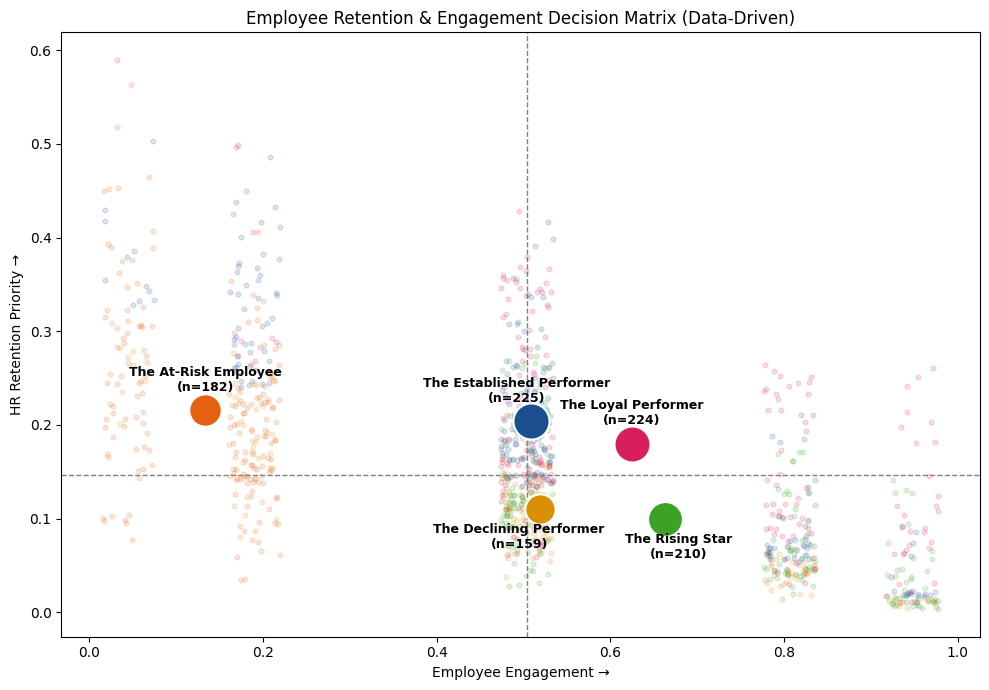

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============ 1. HITUNG SKOR ============
cols = ['PerformanceScore', 'JobSatisfaction', 'YearsAtCompany', 'MonthlyIncome']
df_norm = df_clustering[cols].rank(pct=True)
pay_gap = df_norm['PerformanceScore'] - df_norm['MonthlyIncome']

df_matrix = pd.DataFrame({
    'RiskJS': 1 - df_norm['JobSatisfaction'],
    'RiskGap': pay_gap.clip(lower=0),
    'Impact': (df_norm['PerformanceScore'] + df_norm['MonthlyIncome'] + df_norm['YearsAtCompany']) / 3,
    'Engagement': df_norm['JobSatisfaction'],
}, index=df_clustering.index)

df_matrix['TurnoverRisk'] = (df_matrix['RiskJS'] + df_matrix['RiskGap']) / 2
df_matrix['Priority'] = df_matrix['TurnoverRisk'] * df_matrix['Impact']
df_matrix['Cluster'] = df['Cluster'].values

persona_map = {
    0: 'The Established Performer',
    1: 'The Rising Star',
    2: 'The Loyal Performer',
    3: 'The At-Risk Employee',
    4: 'The Declining Performer',
}
df_matrix['Persona'] = df_matrix['Cluster'].map(persona_map)

centroids = df_matrix.groupby('Persona')[['Engagement', 'Priority']].mean()
pop = df_matrix.groupby('Persona').size()

# ============ 2. PLOT ============
colors = {
    'The At-Risk Employee': '#E4610F',
    'The Loyal Performer': '#D81E5B',
    'The Established Performer': '#1B4F8F',
    'The Declining Performer': '#D98E04',
    'The Rising Star': '#3BA226',
}
offsets = {
    'The At-Risk Employee': (0, 14),
    'The Loyal Performer': (0, 14),
    'The Established Performer': (-10, 14),
    'The Declining Performer': (-15, -28),
    'The Rising Star': (10, -28),
}

x_mid = df_matrix['Engagement'].median()
y_mid = df_matrix['Priority'].median()

rng = np.random.default_rng(42)
fig, ax = plt.subplots(figsize=(10, 7))

# titik individual (jitter horizontal, murni visual)
for p, g in df_matrix.groupby('Persona'):
    jitter = rng.uniform(-0.03, 0.03, len(g))
    ax.scatter(g['Engagement'] + jitter, g['Priority'],
               s=12, alpha=0.15, color=colors[p])

# centroid per persona (ukuran bubble = populasi)
for p, row in centroids.iterrows():
    ax.scatter(row['Engagement'], row['Priority'], s=pop[p] * 3,
               color=colors[p], edgecolor='white', linewidth=1.5, zorder=3)
    ax.annotate(f"{p}\n(n={pop[p]})", (row['Engagement'], row['Priority']),
                textcoords="offset points", xytext=offsets[p],
                ha='center', fontsize=9, fontweight='bold', zorder=4)

# garis kuadran (median split)
ax.axvline(x_mid, color='gray', ls='--', lw=1)
ax.axhline(y_mid, color='gray', ls='--', lw=1)

ax.set_xlabel('Employee Engagement →')
ax.set_ylabel('HR Retention Priority →')
ax.set_title('Employee Retention & Engagement Decision Matrix (Data-Driven)')
plt.tight_layout()
plt.show()

In [67]:
# Tier prioritas individual (threshold dari kuantil populasi)
q75, q50 = df_matrix['Priority'].quantile([0.75, 0.50])

def tier(p):
    if p >= q75: return '🔴 Critical'
    elif p >= q50: return '🟡 Watchlist'
    else: return '🟢 Stable'

df_matrix['PriorityTier'] = df_matrix['Priority'].apply(tier)

In [68]:
pd.crosstab(df_matrix['Persona'], df_matrix['PriorityTier'])

PriorityTier,🔴 Critical,🟡 Watchlist,🟢 Stable
Persona,,,
The At-Risk Employee,68,73,41
The Declining Performer,14,25,120
The Established Performer,92,66,67
The Loyal Performer,66,56,102
The Rising Star,10,30,170


In [69]:
def engagement_level(js):
    if js <= 2: return 'Disengaged'
    elif js == 3: return 'Neutral'
    else: return 'Engaged'      # 4-5

df_matrix['EngagementLevel'] = df_clustering['JobSatisfaction'].apply(engagement_level)

In [70]:
def quadrant(row):
    high_p = row['Priority'] >= df_matrix['Priority'].median()
    engaged = row['EngagementLevel'] == 'Engaged'
    if high_p and not engaged:  return 'Q1 — Urgent Re-engagement'
    if high_p and engaged:      return 'Q2 — Reward & Protect'
    if not high_p and not engaged: return 'Q3 — Monitor / Develop'
    return 'Q4 — Maintain'

df_matrix['Quadrant'] = df_matrix.apply(quadrant, axis=1)

In [71]:
pd.crosstab(df_matrix['Persona'], df_matrix['EngagementLevel'])

EngagementLevel,Disengaged,Engaged,Neutral
Persona,,,
The At-Risk Employee,182,0,0
The Declining Performer,38,45,76
The Established Performer,57,59,109
The Loyal Performer,12,87,125
The Rising Star,0,91,119


In [72]:
# ============ 0. KOLOM REKOMENDASI ============
q50 = df_matrix['Priority'].quantile(0.50)

def rekomendasi(row):
    if row['Priority'] >= q50:                      # prioritas tinggi
        if row['RiskGap'] > row['RiskJS']:
            return 'Compensation Review'
        elif row['RiskJS'] >= 0.5:
            return 'Engagement Intervention'
        else:
            return 'Protect: Career Growth'
    else:
        if df_norm.loc[row.name, 'PerformanceScore'] < 0.4:
            return 'Performance Coaching'
        return 'Maintain & Develop'

df_matrix['Rekomendasi'] = df_matrix.apply(rekomendasi, axis=1)

# ============ 1. RAKIT TABEL PER KARYAWAN ============
df_export = df_clustering[cols].copy()

# identitas & demografi dari df_meta                          # ← diubah
df_export.insert(0, 'EmployeeID', df_meta['EmployeeID'].astype(int).values)
df_export.insert(1, 'Department', df_meta['Department'].values)
df_export.insert(2, 'Gender', df_meta['Gender'].values)
df_export.insert(3, 'Education', df_meta['Education'].values)

df_export['Cluster'] = df_matrix['Cluster']
df_export['Persona'] = df_matrix['Persona']
df_export[['Engagement', 'RiskJS', 'RiskGap', 'TurnoverRisk', 'Impact', 'Priority']] = \
    df_matrix[['Engagement', 'RiskJS', 'RiskGap', 'TurnoverRisk', 'Impact', 'Priority']].round(3)
df_export['PriorityTier'] = df_matrix['PriorityTier']
df_export['EngagementLevel'] = df_matrix['EngagementLevel']
df_export['Rekomendasi'] = df_matrix['Rekomendasi']

df_export = df_export.sort_values('Priority', ascending=False)

# ============ 2. TABEL RINGKASAN ============
cluster_summary = (
    df_matrix.groupby('Persona')
    .agg(Populasi=('Cluster', 'size'),
         TurnoverRisk=('TurnoverRisk', 'mean'),
         Impact=('Impact', 'mean'),
         Priority=('Priority', 'mean'),
         Engagement=('Engagement', 'mean'))
    .round(3)
    .sort_values('Priority', ascending=False)
)

profil_cluster = df_raw_cluster.groupby('Persona')[cols].mean().round(2)
crosstab_tier = pd.crosstab(df_matrix['Persona'], df_matrix['PriorityTier'])
crosstab_rekom = pd.crosstab(df_matrix['Persona'], df_matrix['Rekomendasi'])

# ringkasan per departemen                                     # ← baru
dept_summary = (
    df_export.groupby('Department')
    .agg(Populasi=('EmployeeID', 'size'),
         Critical=('PriorityTier', lambda s: (s == '🔴 Critical').sum()),
         MeanPriority=('Priority', 'mean'),
         MeanEngagement=('Engagement', 'mean'))
    .round(3)
    .sort_values('MeanPriority', ascending=False)
)
crosstab_dept = pd.crosstab(df_export['Department'], df_export['Persona'])

# ============ 3. TULIS KE EXCEL ============
with pd.ExcelWriter('hr_talent_matrix.xlsx', engine='openpyxl') as writer:
    df_export.to_excel(writer, sheet_name='Employee Scores', index=False)
    cluster_summary.to_excel(writer, sheet_name='Cluster Summary')
    profil_cluster.to_excel(writer, sheet_name='Cluster Profile')
    crosstab_tier.to_excel(writer, sheet_name='Persona x Tier')
    crosstab_rekom.to_excel(writer, sheet_name='Persona x Rekomendasi')
    dept_summary.to_excel(writer, sheet_name='Department Summary')             # ← baru
    crosstab_dept.to_excel(writer, sheet_name='Department x Persona')          # ← baru

print('saved: hr_talent_matrix.xlsx')

saved: hr_talent_matrix.xlsx


In [77]:
# ============ 0. REKOMENDASI BERBASIS PERSONA ============
persona_risk = {
    'The At-Risk Employee':      'High early turnover due to low engagement.',
    'The Loyal Performer':       'High turnover risk due to compensation gap.',
    'The Established Performer': 'Risk of losing valuable experienced talent.',
    'The Declining Performer':   'Declining productivity despite long tenure.',
    'The Rising Star':           'Future engagement may decline over time.',
}
persona_need = {
    'The At-Risk Employee':      'Better engagement and manager support.',
    'The Loyal Performer':       'Fair pay and recognition.',
    'The Established Performer': 'Career growth and leadership opportunities.',
    'The Declining Performer':   'Performance improvement and reskilling.',
    'The Rising Star':           'Learning and career development.',
}
persona_action = {
    'The At-Risk Employee':      'Improve engagement through manager support to prevent early turnover.',
    'The Loyal Performer':       'Review compensation immediately to retain critical talent and reduce turnover risk.',
    'The Established Performer': 'Provide career growth to strengthen leadership readiness.',
    'The Declining Performer':   'Improve performance through coaching and reskilling to increase productivity.',
    'The Rising Star':           'Support career development to sustain long-term engagement.',
}

df_matrix['Rekomendasi'] = df_matrix['Persona'].map(persona_action)

hr_solution = pd.DataFrame({
    'Persona': list(persona_action),
    'Cluster': [3, 2, 0, 4, 1],
    'Risk': [persona_risk[p] for p in persona_action],
    'Primary Need': [persona_need[p] for p in persona_action],
    'HR Action': [persona_action[p] for p in persona_action],
})

# ============ 1. RAKIT TABEL PER KARYAWAN ============
df_export = df_clustering[cols].copy()

df_export.insert(0, 'EmployeeID', df_meta['EmployeeID'].astype(int).values)
df_export.insert(1, 'Department', df_meta['Department'].values)
df_export.insert(2, 'Gender', df_meta['Gender'].values)
df_export.insert(3, 'Education', df_meta['Education'].values)

df_export['Cluster'] = df_matrix['Cluster']
df_export['Persona'] = df_matrix['Persona']
df_export[['Engagement', 'RiskJS', 'RiskGap', 'TurnoverRisk', 'Impact', 'Priority']] = \
    df_matrix[['Engagement', 'RiskJS', 'RiskGap', 'TurnoverRisk', 'Impact', 'Priority']].round(3)
df_export['PriorityTier'] = df_matrix['PriorityTier']
df_export['EngagementLevel'] = df_matrix['EngagementLevel']
df_export['Rekomendasi'] = df_matrix['Rekomendasi']

df_export = df_export.sort_values('Priority', ascending=False)

# ============ 2. TABEL RINGKASAN ============
cluster_summary = (
    df_matrix.groupby('Persona')
    .agg(Populasi=('Cluster', 'size'),
         TurnoverRisk=('TurnoverRisk', 'mean'),
         Impact=('Impact', 'mean'),
         Priority=('Priority', 'mean'),
         Engagement=('Engagement', 'mean'))
    .round(3)
    .sort_values('Priority', ascending=False)
)

profil_cluster = df_raw_cluster.groupby('Persona')[cols].mean().round(2)
crosstab_tier = pd.crosstab(df_matrix['Persona'], df_matrix['PriorityTier'])

dept_summary = (
    df_export.groupby('Department')
    .agg(Populasi=('EmployeeID', 'size'),
         Critical=('PriorityTier', lambda s: (s == '🔴 Critical').sum()),
         MeanPriority=('Priority', 'mean'),
         MeanEngagement=('Engagement', 'mean'))
    .round(3)
    .sort_values('MeanPriority', ascending=False)
)
crosstab_dept = pd.crosstab(df_export['Department'], df_export['Persona'])

# ============ 3. TULIS KE EXCEL ============
with pd.ExcelWriter('hr_talent_matrix1.xlsx', engine='openpyxl') as writer:
    df_export.to_excel(writer, sheet_name='Employee Scores', index=False)
    cluster_summary.to_excel(writer, sheet_name='Cluster Summary')
    profil_cluster.to_excel(writer, sheet_name='Cluster Profile')
    crosstab_tier.to_excel(writer, sheet_name='Persona x Tier')
    hr_solution.to_excel(writer, sheet_name='HR Solution', index=False)        # ← baru
    dept_summary.to_excel(writer, sheet_name='Department Summary')
    crosstab_dept.to_excel(writer, sheet_name='Department x Persona')

print('saved: hr_talent_matrix1.xlsx')

saved: hr_talent_matrix1.xlsx


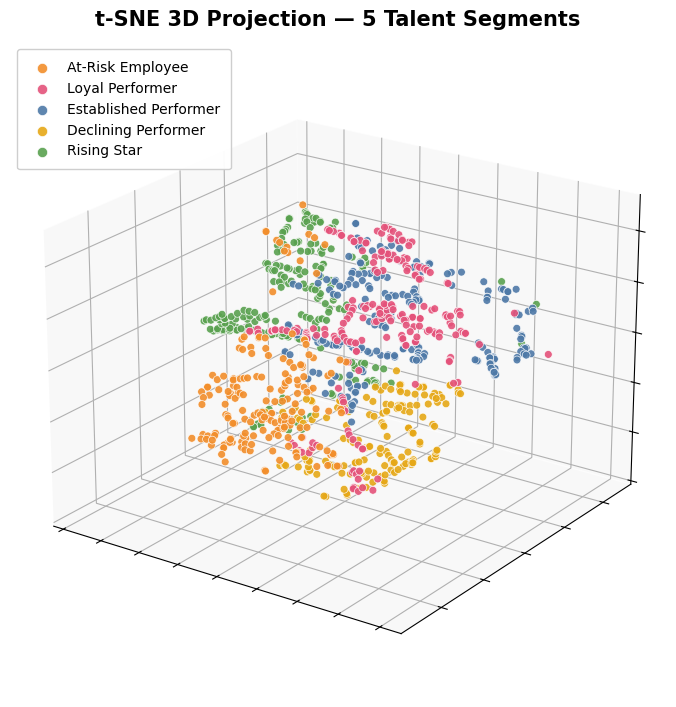

In [78]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

cols = ['PerformanceScore', 'JobSatisfaction', 'YearsAtCompany', 'MonthlyIncome']
X = StandardScaler().fit_transform(df_clustering[cols])
personas = df['Cluster'].map(persona_map).values

colors = {
    'The At-Risk Employee': '#F28E2B',
    'The Loyal Performer': '#E4527A',
    'The Established Performer': '#4E79A7',
    'The Declining Performer': '#E6A817',
    'The Rising Star': '#59A14F',
}

emb = TSNE(n_components=3, perplexity=30, random_state=42,
           init='pca').fit_transform(X)

fig = plt.figure(figsize=(9.5, 8.5))
ax = fig.add_subplot(111, projection='3d')

for p, c in colors.items():
    m = personas == p
    ax.scatter(emb[m, 0], emb[m, 1], emb[m, 2],
               s=32, color=c, alpha=0.9,
               edgecolors='white', linewidths=0.5,
               label=p.replace('The ', ''), depthshade=True)

ax.set_title('t-SNE 3D Projection — 5 Talent Segments',
             fontsize=15, fontweight='bold', pad=12)
ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])
for pane in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
    pane.set_facecolor('#F2F2F2')
    pane.set_edgecolor('#FFFFFF')

ax.legend(loc='upper left', fontsize=10, framealpha=0.95,
          markerscale=1.3, borderpad=0.8)
ax.view_init(elev=22, azim=-55)
plt.show()